## Figure 6,7,8 (parameter exploration) from formation channel paper 

below is the code that reproduces the 2D parameter exploration (simulation silos) exploration 


In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))

# import common_code/PostProcessingScripts which contains default python code used in this jupyter notebook (such as plotting etc.)
sys.path.append('/Users/floorbroekgaarden/Projects/GitHub/common_code/.')
from PostProcessingScripts import * 
from typing import Optional  # change Optional[str] to str | None when using higher versions of python3

In [2]:
## data path
path_to_github_folder = "/Users/floorbroekgaarden/Projects/GitHub/"
path_to_file_folder = "Rates_of_Formation_Channels/plottingCode/All_Figures/Data_formation_channels_intrinsic/"
path_to_file = path_to_github_folder + path_to_file_folder


### Instructions 

for this code to work you will need the following files 
  - `DCOlabel + "_rates_review.csv"` For DCOlabel in BH-BH, BH-NS, and NS-NS  
 you can find this in the Zenodo file or on GitHub inside the Rates_of_Formation_Channels/plottingCode/Fig_comparison/Data_formation_channels_intrinsic/ folder 
  - it imports some functions from the `common_code` file above, but you dont need this :) (just uncomment if needed) 
  - likely you want to change the `save_path` in the code call below 
  

# BBHs, BHNS, and BNS; with SFRD model variations 




In [3]:
import matplotlib.pyplot as plt
import pandas as pd
import os
import numpy as np
import math
from matplotlib.ticker import AutoMinorLocator
import re
%matplotlib inline




## note that this has a duplicate in Figure 3 function, make sure to update both (or in the future, have this file seperate and import it)
def obtain_fc_dict():
    """
    Returns a dictionary defining formation channel (fc) specifications.

    Each top-level key corresponds to a grouping of formation channels 
    (e.g., 'CE_simple', 'CE_detailed', or 'total').  
    Each group contains either a list of 'channels' (with properties) 
    or a single entry (for 'total').
    """


    palette = {
        # Neutrals
        "gray_light":  "#e0e0e0",
        "gray_dark":   "#C2C2C2",

        # Non-CE warm family
        "orange_main": "#FFA630",
        "orange_sub":  "#ffc857",
        "orange_soft": "#f4a259",
        "red_soft":    "#e45756",
        "rose":        "#d96c75",
        "terracotta":  "#bc4b51",
        "peach":       "#ffb5a7",

        # CE cool family
        "blue_main":   "#00A7E1",
        "blue_light":  "#5dade2",
        "blue_mid":    "#0474BA",
        "blue_dark":   "#004e89",
        "indigo":      "#3a3d98",   # new deep indigo for AIC
        "teal_light":  "#20b2aa",
        "green_blue":  "#58AD8B",
        "aqua":        "#00bfc4",
        "seafoam":     "#8dd3c7",
        "mint":        "#9de0ad",
    }


    fc_dict = {
        # A simplified common-envelope grouping (just two channels).
        "CE_simple": {
            "channels": [
                {"name": "fraction without common envelope", "color":palette["orange_main"], "hatch": '...', "label":'without common envelope', "axlabel":"fraction without CE"},
                {"name": "fraction with common envelope",    "color":palette["blue_main"],   "hatch": '//' , "label":'with common envelope', "axlabel":"fraction with CE"},
                {"name": "fraction not specified",           "color":palette[ "gray_dark"],  "hatch":None,   "label":'not specified'}
            ],
            "label_ncols":3
        },

        
        "CE_detailed": {
            "channels": [
                
                # --- Non-CE channels (warm hues, all unique) ---
                {"name": "without CE (no detail specified)", "color":palette["orange_main"], "hatch": '...', "label":'without common envelope'},
                {"name": "SMT before and after channel",     "color":palette["red_soft"],    "hatch": '...', "label":'classic only stable'},
                {"name": "SMT+NON",                          "color":palette["rose"],        "hatch": '...', "label":'SMT + NON'},
                {"name": "NON+SMT",                          "color":palette["orange_soft"], "hatch": '...', "label":'NON+SMT'},
                {"name": "NON + NON",                        "color":palette["terracotta"],  "hatch": '...', "label":'NON+NON'},
                {"name": "channel V intrinsic (z=0) other without CE", "color":palette["peach"], "hatch": 'ooo', "label":'other without CE'},
                {"name": "CHE",                              "color":palette["orange_sub"],     "hatch":'...',   "label":'CHE (no MT)'},
                # --- CE channels (cool hues, all unique) ---
                {"name": "with CE (no detail specified)",                 "color":palette["blue_main"],  "hatch": "\\", "label":'with common envelope'},
                
                {"name": "channel I intrinsic (z=0) classic CE (SMT+CE)", "color":palette["blue_light"], "hatch": "//", "label":'classic CE'},
                {"name": "channel III intrinsic (z=0) SCCE",              "color":palette["blue_mid"],   "hatch": "\\", "label":'single-core CE'},
                {"name": "channel IV intrinsic (z=0) DCCE",               "color":palette["teal_light"], "hatch": '//', "label":'double-core CE'},
                
                {"name": "CEE + SMT",                                     "color":palette["green_blue"], "hatch": '//', "label":'CEE + SMT'},
                {"name": "CEE+CEE",                                       "color":palette["aqua"],       "hatch": "\\", "label":'CEE+CEE'},
                {"name": "NON+CEE",                                       "color":palette["seafoam"],    "hatch": '//', "label":'NON+CEE'},
                {"name": "CEE+NON",                                       "color":palette["mint"],       "hatch": '//', "label":'CEE+NON'},

                {"name": "channel radCEE",  "color":palette["blue_dark"], "hatch": '\\', "label":'radiative CE'},
                {"name": "channel convCEE", "color":palette["teal_light"], "hatch": '//', "label":'convective CE'},
                {"name": "channel V intrinsic (z=0) other with CE", "color":palette["seafoam"], "hatch": "\\", "label":'other with CE'},
                {"name": "channel AIC with CE", "color":palette["indigo"], "hatch": '//', "label":'AIC with CE'},


                {"name": "channel V intrinsic (z=0) CE not specified",    "color":palette["gray_dark"],  "hatch": None, "label":'other CE not specified'},
            ],
            "label_ncols":5
        },

        # A total merger rate across all intrinsic channels.
        "total": {
            "name": "All intrinsic (z=0) [Gpc^-3 yr^-1]",
            "color": "black",
            "hatch": None,
            "label":r"All intrinsic ($z\sim0$) \ $[\rm{Gpc}^{-3} \rm{yr}^{-1}$]",
            "label_ncols":1,
            "axlabel":r"$\mathcal{R}_{\rm{m}}$ \  $[\rm{Gpc}^{-3} \rm{yr}^{-1}$]"
#             "axlabel":r"Total local merger rate", # % ($z=0$) \ $[\rm{Gpc}^{-3} \rm{yr}^{-1}$]
        },
    }

    return fc_dict


mpl.rcParams['hatch.linewidth'] = 0.5   # default is 1.0
mpl.rcParams['hatch.color'] = 'darkslategray'   # optional: set hatch color




def normalize_study_label(label):
    return str(label).strip()


def build_global_study_color_map(
    path_to_file,
    dco_labels=("BH-BH", "BH-NS", "NS-NS"),
    cmap_name="husl",
):
    """
    Build one consistent color map across all DCO relation files.
    Same study label gets same color for BBH/BHNS/BNS.
    """
    all_studies = []

    for dco in dco_labels:
        relation_file = f"{dco}_fcRelations.csv"
        rel_path = os.path.join(path_to_file, relation_file)

        if not os.path.exists(rel_path):
            continue

        df_rel = pd.read_csv(rel_path)

        if "legend" not in df_rel.columns:
            continue

        studies = df_rel["legend"].dropna().map(normalize_study_label).unique()
        all_studies.extend(studies)

    all_studies = sorted(set(all_studies))

    if cmap_name.lower() == "husl":
        palette = sns.color_palette("husl", len(all_studies))
    else:
        cmap = plt.get_cmap(cmap_name)
        palette = [cmap(i / max(1, len(all_studies) - 1)) for i in range(len(all_studies))]

    return {study: palette[i] for i, study in enumerate(all_studies)}



def plot_withoutCE_all_and_by_study(
    path_to_file,
    DCOlabel="BH-BH",
    broek_sfrd_path=None,
    relation_file=None,
    marker="o",
    size=50,
    line_alpha=0.7,
    line_style="-",
    line_width=2.5,
    figsize_all=(8, 6),
    ncols_grid=5,
    figsize_grid_per_panel=(4.0, 3.2),  # (width, height) per subplot
    cmap_name="tab20",
    sharex=True,
    sharey=True,
    save_big_pdf=None,
    save_grid_pdf=None,
    dpi=300,
    x_quantity="fraction",   # "fraction" or "absolute_rate"
    xscale=None,             # optional override
    annotate_models=None,    # whether to annotate some model data points 
    study_color_map=None,    # use consistent color mapping for simulation sets? 
):
    """
    Make:
      (1) one big plot: fraction without CE vs total intrinsic rate for all studies
      (2) a subplot grid: same relation, one panel per study (legend)

    Returns
    -------
    fig_all, ax_all, fig_grid, axes_grid
    """
    
    
    
    if annotate_models is None:
        annotate_models = []
    annotate_models = set(annotate_models)
    
    
    
    def map_dco_label_for_broek_file(dco_label: str) -> str:
        """
        Map plotting labels like 'BH-BH' to file labels like 'BHBH'.
        """
        mapping = {
            "BH-BH": "BHBH",
            "BH-NS": "BHNS",
            "NS-NS": "NSNS",
            "BHBH": "BHBH",
            "BHNS": "BHNS",
            "NSNS": "NSNS",
        }
        if dco_label not in mapping:
            raise ValueError(f"Unsupported DCOlabel: {dco_label}")
        return mapping[dco_label]
    

    # --- Load relation file (pairs of models) ---
    if relation_file is None:
        relation_file = f"{DCOlabel}_fcRelations.csv"
    df_rel = pd.read_csv(os.path.join(path_to_file, relation_file))

    # --- Load rates file (fractions + total rate per model) ---
    rates_file = f"{DCOlabel}_rates_review.csv"
    df_rates = pd.read_csv(os.path.join(path_to_file, rates_file))
    df_rates = df_rates.fillna(0.0).set_index("model")
    
    
    
    # --- Load simulation specs for code labels ---
    specs_path = os.path.join(path_to_file, "simulation_specs.csv")
    if os.path.exists(specs_path):
        df_specs = pd.read_csv(specs_path).fillna("")
    else:
        df_specs = pd.DataFrame()
        
        
    def get_label_1(modelname):
        if df_specs.empty:
            return ""

        model_col = "model" if "model" in df_specs.columns else "name"
        if model_col not in df_specs.columns or "label_1" not in df_specs.columns:
            return ""

        match = df_specs.loc[df_specs[model_col] == modelname, "label_1"]

        if len(match) == 0:
            return ""

        return str(match.iloc[0]).strip()    
    

    def get_code_label_for_study(df_sub):
        if df_specs.empty or "code" not in df_specs.columns:
            return ""

        model_col = "model" if "model" in df_specs.columns else "name"
        if model_col not in df_specs.columns:
            return ""

        models = set(df_sub["from_modelname"]).union(set(df_sub["to_modelname"]))
        codes = (
            df_specs.loc[df_specs[model_col].isin(models), "code"]
            .astype(str)
            .str.strip()
            .replace("", np.nan)
            .dropna()
            .unique()
        )

        return ", ".join(sorted(codes))
    
    

    # --- OPTIONAL: load van Son 2023 secondary SFRD variations ---
    vanson_sfrd_file = os.path.join(path_to_file, "extra_fc_rates", "vanSon2023_sfrd.csv")
    if os.path.exists(vanson_sfrd_file):
        df_rates_vanson_sfrd = pd.read_csv(vanson_sfrd_file).fillna(0.0).set_index("model")
    else:
        df_rates_vanson_sfrd = None
    
    # --- OPTIONAL: load Broekgaarden secondary SFRD/S(Z,z) variations ---
    broek_file_label = map_dco_label_for_broek_file(DCOlabel)

    if broek_sfrd_path is None:
        broek_sfrd_file = os.path.join(
            path_to_file,
            "extra_fc_rates",
            f"Broekgaarden_{broek_file_label}_all_SFRD_variations_combined.csv"
        )
    else:
        # allow either a direct file path OR a folder path
        if os.path.isdir(broek_sfrd_path):
            broek_sfrd_file = os.path.join(
                broek_sfrd_path,
                f"Broekgaarden_{broek_file_label}_all_SFRD_variations_combined.csv"
            )
        else:
            broek_sfrd_file = broek_sfrd_path

    print("Looking for Broekgaarden SFRD file at:", broek_sfrd_file)
    print("Exists?", os.path.exists(broek_sfrd_file))

    if os.path.exists(broek_sfrd_file):
        df_rates_broek_sfrd = pd.read_csv(broek_sfrd_file).fillna(0.0)
        print("Loaded Broekgaarden SFRD rows:", len(df_rates_broek_sfrd))
        print("Columns:", list(df_rates_broek_sfrd.columns))
    else:
        df_rates_broek_sfrd = None
        print("Broekgaarden SFRD file not loaded.")
        
        
        
        
        
    

    # --- Formation-channel metadata ---
    fc_dict = obtain_fc_dict()
    fc_total_header = fc_dict["total"]["name"]      # column name for total intrinsic rate
    yname = fc_dict["total"]["axlabel"]             # y-axis label (rate)

    # x axis label for "fraction without common envelope"
    channels = fc_dict["CE_simple"]["channels"]
    channel_dict = next(ch for ch in channels if ch["name"] == "fraction without common envelope")

    if x_quantity == "fraction":
        xname = channel_dict["axlabel"]
    elif x_quantity == "absolute_rate":
        xname = r"$\mathcal{R}_{\rm without\ CE}$ \  $[\rm{Gpc}^{-3} \rm{yr}^{-1}$]"
    else:
        raise ValueError(f"Unsupported x_quantity: {x_quantity}")

    # --- Studies (legend groups) ---
    legends = list(df_rel["legend"].dropna().unique())
    legends_sorted = sorted(legends)

    # --- Color map ---
    if study_color_map is None:
        study_color_map = build_global_study_color_map(path_to_file, cmap_name=cmap_name)

    color_map = {
        leg: study_color_map.get(normalize_study_label(leg), "k")
        for leg in legends_sorted
    }

    # --- explicitly set van Son 2023 study + fiducial model ---
    vanSon_legend = "van Son (2023) "
    vanSon_fiducial_model = "van Son (2023) "
    # --- explicitly set Broekgaarden study label ---
    broek_legend = None
    for leg in legends_sorted:
        leg_clean = str(leg).strip().lower()
        if "broekgaarden" in leg_clean:
            broek_legend = leg
            break

    print("Using broek_legend =", repr(broek_legend))
    print("Using vanSon_legend =", repr(vanSon_legend))
    print("Using vanSon_fiducial_model =", repr(vanSon_fiducial_model))
    print("Using broek_legend =", repr(broek_legend))
    
    
    def get_x_from_main_df(df, model, x_quantity="fraction"):
        """
        Return x-value for a model from the main rates dataframe.
        """
        frac = float(df.loc[model, "fraction without common envelope"])
        total = float(df.loc[model, fc_total_header])

        if x_quantity == "fraction":
            return frac
        elif x_quantity == "absolute_rate":
            return frac * total
        else:
            raise ValueError(f"Unsupported x_quantity: {x_quantity}")

    def get_x_from_secondary_values(frac, total, x_quantity="fraction"):
        """
        Return x-value from already-extracted fraction/total values
        (useful for auxiliary SFRD files).
        """
        frac = float(frac)
        total = float(total)

        if x_quantity == "fraction":
            return frac
        elif x_quantity == "absolute_rate":
            return frac * total
        else:
            raise ValueError(f"Unsupported x_quantity: {x_quantity}")    

    # ------------- helper: plot a set of relations onto an axis -------------
    def plot_relations_on_ax(ax, df_rel_subset, legend_for_color=None):
        """
        Plot points for models and connect from->to for each row in df_rel_subset.
        If legend_for_color is None, color per row's legend.
        """
        for _, row in df_rel_subset.iterrows():
            leg = row["legend"]
            color = color_map[legend_for_color] if legend_for_color is not None else color_map.get(leg, "k")

            m_from = row["from_modelname"]
            m_to = row["to_modelname"]

            coords = {}
            for model in [m_from, m_to]:
                if model not in df_rates.index:
                    continue

                x = get_x_from_main_df(df_rates, model, x_quantity=x_quantity)
                y = float(df_rates.loc[model, fc_total_header])
                coords[model] = (x, y)

                ax.scatter(
                    x, y,
                    s=size,
                    c=[color],
                    marker=marker,
                    edgecolor="k",
                    linewidths=0.5,
                    zorder=10
                )

            if m_from in coords and m_to in coords:
                (x1, y1) = coords[m_from]
                (x2, y2) = coords[m_to]
                ax.plot(
                    [x1, x2], [y1, y2],
                    color=color,
                    linestyle=line_style,
                    linewidth=line_width,
                    alpha=line_alpha,
                    zorder=5
                )

    # ------------- helper: plot van Son 2023 secondary SFRD variations -------------
    def plot_vanSon2023_secondary_sfrd(ax, legend_for_color):
        """
        Add the secondary S(Z,z)/SFRD variations for van Son 2023:
        - same color as van Son 2023
        - behind the main relations
        - each extra point connected to the fiducial main-model point
        """
        if df_rates_vanson_sfrd is None:
            return
        if legend_for_color is None:
            return
        if vanSon_fiducial_model is None:
            return
        if vanSon_fiducial_model not in df_rates.index:
            return
        if legend_for_color != vanSon_legend:
            return

        color = color_map[legend_for_color]

        # fiducial point from the MAIN rates file
        x_fid = get_x_from_main_df(df_rates, vanSon_fiducial_model, x_quantity=x_quantity)
        y_fid = float(df_rates.loc[vanSon_fiducial_model, fc_total_header])

        # plot all extra points except any duplicate fiducial row in the extra csv
        for model in df_rates_vanson_sfrd.index:
            if "Fiducial" in str(model):
                continue

            frac = df_rates_vanson_sfrd.loc[model, "fraction without common envelope"]
            y = float(df_rates_vanson_sfrd.loc[model, fc_total_header])
            x = get_x_from_secondary_values(frac, y, x_quantity=x_quantity)

            # faint background line to fiducial
            ax.plot(
                [x_fid, x], [y_fid, y],
                color=color,
                linestyle="-",
                linewidth=line_width * 0.45,
                alpha=0.54,
                zorder=0
            )


            # faint background point
            ax.scatter(
                x, y,
                s=size * 0.28,
                c=[color],
                marker=marker,
                edgecolor="none",
                linewidths=0.0,
                alpha=0.18,
                zorder=1
            )
    
    
    
    # ------------- helper: plot Broekgaarden secondary SFRD variations -------------
    def plot_broekgaarden_secondary_sfrd(ax, legend_for_color):
        """
        Add the secondary S(Z,z)/SFRD variations for the Broekgaarden study:
        - same color as Broekgaarden study
        - behind the main relations
        - each extra point connected to the corresponding main-model point
          by matching model_name A/B/.../T to df_rates models like B22-A-fiducial
        """
        print("\n--- plot_broekgaarden_secondary_sfrd ---")
        print("legend_for_color =", repr(legend_for_color))
        print("broek_legend     =", repr(broek_legend))

        if df_rates_broek_sfrd is None:
            print("EXIT: df_rates_broek_sfrd is None")
            return
        if legend_for_color is None:
            print("EXIT: legend_for_color is None")
            return
        if broek_legend is None:
            print("EXIT: broek_legend is None")
            return
        if str(legend_for_color).strip() != str(broek_legend).strip():
            print("EXIT: legend mismatch")
            return
        if legend_for_color not in color_map:
            print("EXIT: legend_for_color not in color_map")
            return

        color = color_map[legend_for_color]

        # Build mapping letter -> main Broekgaarden fiducial model
        main_model_map = {}

        # First pass: explicitly prefer fiducial rows
        for letter in list("ABCDEFGHIJKLMNOPQRST"):
            fid_candidates = [
                str(model).strip()
                for model in df_rates.index
                if re.match(rf"^[A-Z0-9]+-{letter}-fiducial$", str(model).strip(), flags=re.IGNORECASE)
            ]
            if len(fid_candidates) > 0:
                main_model_map[letter] = fid_candidates[0]

        # Second pass: fallback to first B22-letter-* match if no fiducial exists
        for model in df_rates.index:
            model_str = str(model).strip()
            m = re.match(r"^[A-Z0-9]+-([A-T])-", model_str, flags=re.IGNORECASE)
            if m:
                letter = m.group(1).upper()
                if letter not in main_model_map:
                    main_model_map[letter] = model_str


        n_plotted = 0

        for _, row in df_rates_broek_sfrd.iterrows():
            letter = str(row["model_name"]).strip().upper()

            if letter not in main_model_map:
                continue

            main_model = main_model_map[letter]

            # Main point from BH-BH_rates_review.csv
            x_fid = get_x_from_main_df(df_rates, main_model, x_quantity=x_quantity)
            y_fid = float(df_rates.loc[main_model, fc_total_header])

            # Background S(Z,z) variation point
            frac = float(row["without_CE_fraction"])
            y = float(row["total_rate"])
            x = get_x_from_secondary_values(frac, y, x_quantity=x_quantity)

            if not np.isfinite(x) or not np.isfinite(y):
                continue
            if y <= 0:
                continue

            # faint background line
            ax.plot(
                [x_fid, x], [y_fid, y],
                color=color,
                linestyle="-",
                linewidth=line_width * 0.45,
                alpha=0.34,
                zorder=0
            )

            # faint background point
            ax.scatter(
                x, y,
                s=size * 0.28,
                c=[color],
                marker=marker,
                edgecolor="none",
                linewidths=0.0,
                alpha=0.18,
                zorder=1
            )

            n_plotted += 1

        print("Broekgaarden extra points plotted:", n_plotted)
    
    
    
    def annotate_selected_models(ax, df_rates, df_specs, annotate_models, df_sub=None):
        if not annotate_models:
            return

        model_col = "model"

        for model in annotate_models:

            # Only annotate in subpanels where this model appears in the relation table
            if df_sub is not None:
                models_in_panel = set(df_sub["from_modelname"]).union(set(df_sub["to_modelname"]))

                if model not in models_in_panel:
                    continue

            if model not in df_rates.index:
                print(f"Warning: {model} not found in rates table")
                continue

            if model not in set(df_specs[model_col]):
                print(f"Warning: {model} not found in specs table")
                continue

            x = get_x_from_main_df(df_rates, model, x_quantity=x_quantity)
            y = float(df_rates.loc[model, fc_total_header])

            label = df_specs.loc[df_specs[model_col] == model, "label_1"].iloc[0]
            
            if model in ["DT22-M11", "DT22-M6", "Boesky_alphaCE_0_1_beta0_75"]: # overwrite with second label that is more dominant 
                label = df_specs.loc[df_specs[model_col] == model, "label_2"].iloc[0]

            elif model in ["RG21-noBH-kick-SN:delayed", "RG21-ECSN:Full-SN:delayed", "Olejak21-M481 (changedCEcriteria+switch)", "RG21-SN:delayed", "RG21-noBHkick-SN:N20"]: # overwrite with both labels that are dominant 
                label_0 = df_specs.loc[df_specs[model_col] == model, "label_2"].iloc[0]
                label_1 = df_specs.loc[df_specs[model_col] == model, "label_1"].iloc[0]
                label = label_0 + '\n' + label_1
                
            elif model in ["Boesky_sigma_750_RMP_M", "Boesky_alphaCE_0_1_beta0_25", "Boesky_alphaCE_0_1_beta0_75"]:
                label_0 = df_specs.loc[df_specs[model_col] == model, "label_1"].iloc[0]
                label_1 = df_specs.loc[df_specs[model_col] == model, "label_2"].iloc[0]
                label_2 = df_specs.loc[df_specs[model_col] == model, "label_3"].iloc[0]
                label = label_0 + '\n' + label_1 +  '\n' + label_2

            xmin, xmax = -0.1, 1.05
            ymin, ymax = ax.get_ylim()
            
            # axes fraction not absolute 
            x_frac =  x #(x - xmin) / (xmax - xmin)

            if x_frac > 0.9:
                xytext = (-8, 8)
                ha = "center"
            elif x_frac < 0.15:
                xytext = (8, 8)
                ha = "center"
            elif (x_frac >= 0.15) & (x_frac < 0.35):
                xytext = (0, 12)
                ha = "center"      
            elif (x_frac >= 0.35) & (x_frac < 0.5):
                xytext = (8, 10)
                ha = "center"  
            elif (x_frac >= 0.5) & (x_frac <= 0.9):
                xytext = (12, 8)
                ha = "center"              


            ax.annotate(
                str(label),
                xy=(x, y),
                xytext=xytext,
                textcoords="offset points",
                fontsize=8,
                ha=ha,
                va="bottom",
                bbox=dict(
                    boxstyle="round,pad=0.2",
                    facecolor="white",
                    edgecolor="none",
                    alpha=0.8,
                ),
                zorder=30,
                clip_on=True,
            )
    
    
    
    # ===================== (1) BIG PLOT: all studies =====================
    fig_all, ax_all = plt.subplots(1, 1, figsize=figsize_all)

    plot_relations_on_ax(ax_all, df_rel)

    # axes styling
    layoutAxes(ax_all, nameX=xname, nameY=yname, fontsize=20)
    if xscale is None:
        xscale_use = "linear" if x_quantity == "fraction" else "log"
    else:
        xscale_use = xscale

    ax_all.set_xscale(xscale_use)
    ax_all.set_yscale("log")
    ax_all.grid(True, alpha=0.3)
    if x_quantity == "fraction":
        ax_all.set_xlim(0, 1)

    # legend (one handle per study)
    handles = []
    for leg in legends_sorted:
        handles.append(
            plt.Line2D([], [], color=color_map[leg], marker=marker, linestyle="",
                       markersize=2*np.sqrt(size)/2, markeredgecolor="k", label=leg)
        )
#     if DCOlabel=='NS-NS':ncol_lab=3
#     else: ncol_lab=2
        
    ax_all.legend(handles=handles, loc="best", frameon=False, ncol=2, fontsize=10)
        
    fig_all.tight_layout()
    
    

    # ===================== (2) GRID: one panel per study =====================
    n_studies = len(legends_sorted)
    ncols = int(ncols_grid)
    nrows = int(math.ceil(n_studies / ncols))

    fig_grid_w = figsize_grid_per_panel[0] * ncols
    fig_grid_h = figsize_grid_per_panel[1] * nrows
    fig_grid, axes = plt.subplots(
        nrows, ncols,
        figsize=(fig_grid_w, fig_grid_h),
        sharex=sharex,
        sharey=sharey
    )

    # Flatten axes robustly
    axes_flat = np.array(axes).reshape(-1)

    # --- style knobs (tweak to taste) ---
    tick_labelsize = 15
    tick_length_major = 8
    tick_length_minor = 4
    tick_width = 1.
    panel_labelsize = 14

    for i, leg in enumerate(legends_sorted):
        ax = axes_flat[i]
        df_sub = df_rel[df_rel["legend"] == leg]

        # plot this study
        plot_relations_on_ax(ax, df_sub, legend_for_color=leg)

        # add van Son 2023 secondary SFRD variations only in the van Son panel
        if str(leg).strip() == str(vanSon_legend).strip():
            plot_vanSon2023_secondary_sfrd(ax, vanSon_legend)
        
        # add Broekgaarden secondary SFRD variations only in the Broekgaarden panel
        if str(leg).strip() == str(broek_legend).strip():
            plot_broekgaarden_secondary_sfrd(ax, broek_legend)
        
        # scales/grid
        ax.set_xscale(xscale_use)
        ax.set_yscale("log")
        ax.grid(True, alpha=0.25)

        # --- study name: top-left inside panel ---
        ax.text(
            0.98, 0.05, r'$\textbf{%s}$'%str(leg),
            transform=ax.transAxes,
            ha="right",
            va="bottom",
            fontsize=14,
            fontweight="bold",
            bbox=dict(
                boxstyle="round,pad=0.25",
                facecolor="white",
                alpha=0.75,
                edgecolor="none"
            ),
            zorder=20
        )

        # --- code label: bottom-left inside panel ---
        code_label = get_code_label_for_study(df_sub)

        if code_label:
            ax.text(
                0.03, 0.05, code_label,
                transform=ax.transAxes,
                ha="left",
                va="bottom",
                fontsize=9,
                fontweight="normal",
                color="0.25",
                bbox=dict(
                    boxstyle="round,pad=0.20",
                    facecolor="white",
                    alpha=0.65,
                    edgecolor="none"
                ),
                zorder=20
            )
        

        # --- ticks: bigger labels, shorter ticks, minor ticks on x ---
        ax.tick_params(
            axis="both", which="major",
            labelsize=tick_labelsize,
            length=tick_length_major,
            width=tick_width,
            direction="in"
        )
        ax.tick_params(
            axis="both", which="minor",
            labelsize=tick_labelsize,
            length=tick_length_minor,
            width=tick_width,
            direction="in"
        )

        # minor ticks on x-axis
        ax.xaxis.set_minor_locator(AutoMinorLocator(2))
        ax.tick_params(axis="x", which="minor", bottom=True)
        

        # --- annotate selected outlier models ---
        annotate_selected_models(
            ax=ax,
            df_rates=df_rates,
            df_specs=df_specs,
            annotate_models=annotate_models,
            df_sub=df_sub
        )
        
        
        # ---------- soft background grid ----------
        ax.grid(
            True,
            which="major",
            linestyle="--",
            linewidth=0.6,
            alpha=0.26,
            zorder=0,
        )

        ax.grid(
            True,
            which="minor",
            linestyle=":",
            linewidth=0.4,
            alpha=0.14,
            zorder=0,
        )

        
        

    # Turn off unused axes
    for j in range(n_studies, len(axes_flat)):
        axes_flat[j].axis("off")

    label_fontsize = 20
    ylabel_pad = 15

    if sharex:
        fig_grid.supxlabel(
            r'$\textbf{%s}$'%xname,
            fontsize=label_fontsize,
            y=0.02
        )

    if sharey:
        fig_grid.supylabel(
            r'$\textbf{%s}$'%yname,
            fontsize=label_fontsize,
            x=0.01
        )

    # --- remove spacing between subpanels ---
    fig_grid.subplots_adjust(left=0.06, right=0.995, bottom=0.06, top=0.995,
                             wspace=0.0, hspace=0.0)

    fig_grid.tight_layout()
    
    
    # --- make big panel match grid/subpanel limits ---
    valid_axes = [ax for ax in axes_flat[:n_studies] if ax.has_data()]

    if len(valid_axes) > 0:
        common_xlim = valid_axes[0].get_xlim()
        common_ylim = valid_axes[0].get_ylim()

        ax_all.set_xlim(common_xlim)
        ax_all.set_ylim(common_ylim)
    

    # ===================== SAVE FIGURES =====================
    if save_big_pdf is not None:
        fig_all.savefig(
            save_big_pdf,
            format="pdf",
            bbox_inches="tight",
            dpi=dpi,
            transparent=True
        )
        print(f"Saved big plot to: {save_big_pdf}")

    if save_grid_pdf is not None:
        fig_grid.savefig(
            save_grid_pdf,
            format="pdf",
            bbox_inches="tight",
            dpi=dpi,
            transparent=True
        )
        print(f"Saved grid plot to: {save_grid_pdf}")

    return fig_all, ax_all, fig_grid, axes

import os



def make_withoutCE_plots(
    DCOlabel: str,
    base_plot_path: str = "/Users/floorbroekgaarden/Projects/GitHub/Rates_of_Formation_Channels/plottingCode/All_Figures/Data_formation_channels_intrinsic/",
    output_fig_path: str = "/Users/floorbroekgaarden/Projects/GitHub/Rates_of_Formation_Channels/plottingCode/All_Figures/",
    cmap_name: str = "husl",
    show: bool = True,
    ncols_grid=5,
    x_quantity="fraction",
    xscale=None,
    annotate_models=None
):
    """
    Wrapper to generate and save without-CE plots with consistent settings.
    """

    # ---------------- map label for filenames ----------------
    label_map = {
        "BH-BH": "BHBH",
        "BH-NS": "BHNS",
        "NS-NS": "NSNS",
        "BHBH": "BHBH",
        "BHNS": "BHNS",
        "NSNS": "NSNS",
    }

    if DCOlabel not in label_map:
        raise ValueError(f"Unsupported DCOlabel: {DCOlabel}")

    file_label = label_map[DCOlabel]

    # ---------------- paths ----------------
    data_path = base_plot_path

    # ensure output directory exists
    os.makedirs(output_fig_path, exist_ok=True)

    # Broekgaarden background file
    broek_dir = os.path.join(data_path, "extra_fc_rates")
    broek_file = os.path.join(
        broek_dir,
        f"Broekgaarden_{file_label}_all_SFRD_variations_combined.csv"
    )

    if not os.path.exists(broek_file):
        print(f"WARNING: Broekgaarden file not found:\n{broek_file}")
        broek_file = None

    # ---------------- output filenames ----------------
    save_big = os.path.join(
        output_fig_path,
        'Output_Figures/Fig6+_' +  f"{file_label}_fraction_withoutCE_all.pdf"
    )

    save_grid = os.path.join(
        output_fig_path,
        'Output_Figures/Fig6+_' + f"{file_label}_fraction_withoutCE_grid.pdf"
    )

    print("\n==============================")
    print(f"Running for {DCOlabel}")
    print("Saving figures to:", output_fig_path)
    
    # build consistent color map for all simulations 
    study_color_map = build_global_study_color_map(
        data_path,
        cmap_name=cmap_name,
    )


    # ---------------- call plotting function ----------------
    fig_all, ax_all, fig_grid, axes_grid = plot_withoutCE_all_and_by_study(
        path_to_file=data_path,
        DCOlabel=DCOlabel,
        broek_sfrd_path=broek_file,
        cmap_name=cmap_name,
        save_big_pdf=save_big,
        save_grid_pdf=save_grid,
        ncols_grid=ncols_grid,
        figsize_all=(9, 6),
        figsize_grid_per_panel=(4.2, 3.2),
        x_quantity=x_quantity,
        xscale=xscale,
        annotate_models=annotate_models,
        study_color_map=study_color_map,
    )

    if show:
        import matplotlib.pyplot as plt
        plt.show()

    return fig_all, ax_all, fig_grid, axes_grid




Running for BH-BH
Saving figures to: /Users/floorbroekgaarden/Projects/GitHub/Rates_of_Formation_Channels/plottingCode/All_Figures/
Looking for Broekgaarden SFRD file at: /Users/floorbroekgaarden/Projects/GitHub/Rates_of_Formation_Channels/plottingCode/All_Figures/Data_formation_channels_intrinsic/extra_fc_rates/Broekgaarden_BHBH_all_SFRD_variations_combined.csv
Exists? True
Loaded Broekgaarden SFRD rows: 560
Columns: ['DCOlabel', 'SFRD_variation', 'source_file', 'model_name', 'total_rate', 'without_CE_fraction', 'with_CE_fraction', 'sum_CE_fractions', 'sum_minus_one', 'fractions_sum_to_one']
Using broek_legend = 'Broekgaarden (2022)'
Using vanSon_legend = 'van Son (2023) '
Using vanSon_fiducial_model = 'van Son (2023) '
Using broek_legend = 'Broekgaarden (2022)'

--- plot_broekgaarden_secondary_sfrd ---
legend_for_color = 'Broekgaarden (2022)'
broek_legend     = 'Broekgaarden (2022)'
Broekgaarden extra points plotted: 557
Saved big plot to: /Users/floorbroekgaarden/Projects/GitHub/Ra

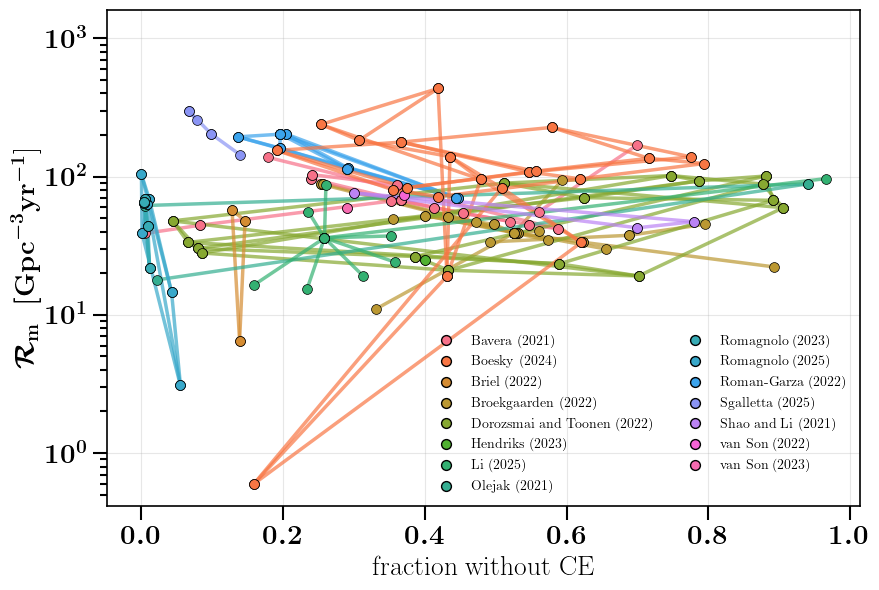

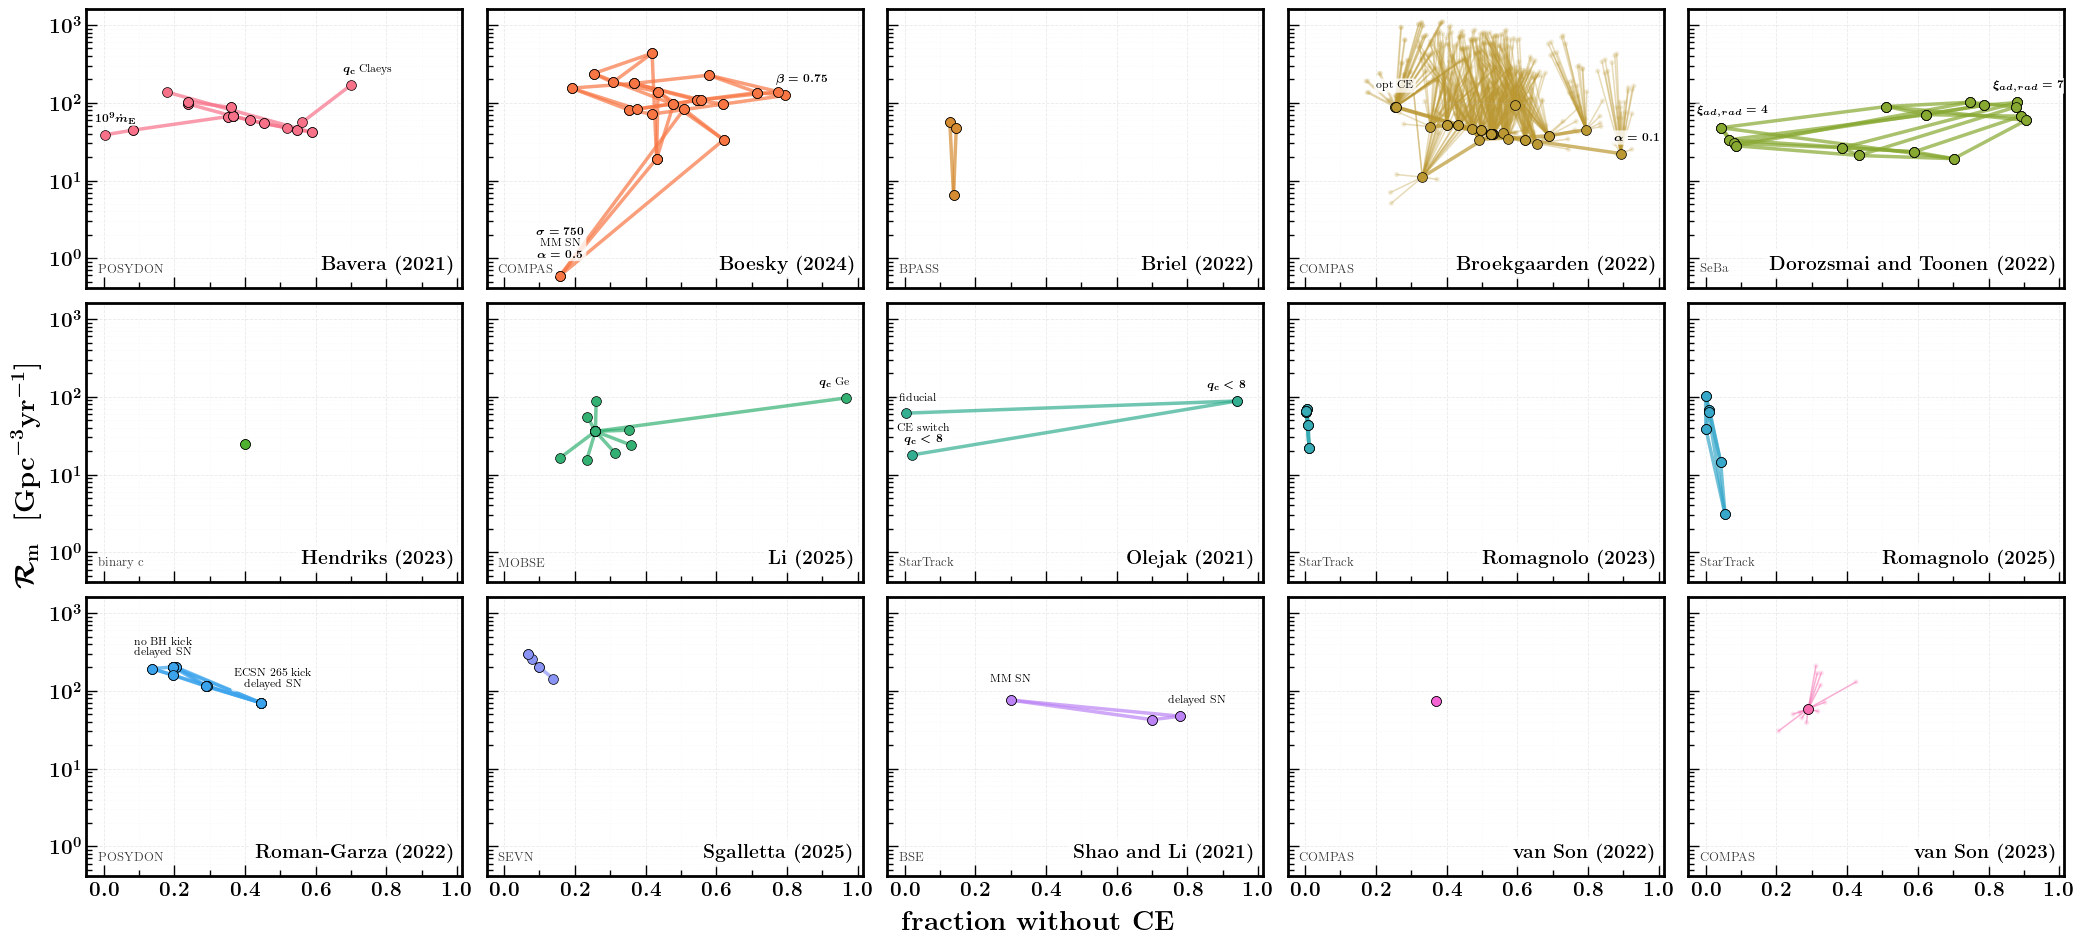


Running for BH-NS
Saving figures to: /Users/floorbroekgaarden/Projects/GitHub/Rates_of_Formation_Channels/plottingCode/All_Figures/
Looking for Broekgaarden SFRD file at: /Users/floorbroekgaarden/Projects/GitHub/Rates_of_Formation_Channels/plottingCode/All_Figures/Data_formation_channels_intrinsic/extra_fc_rates/Broekgaarden_BHNS_all_SFRD_variations_combined.csv
Exists? True
Loaded Broekgaarden SFRD rows: 560
Columns: ['DCOlabel', 'SFRD_variation', 'source_file', 'model_name', 'total_rate', 'without_CE_fraction', 'with_CE_fraction', 'sum_CE_fractions', 'sum_minus_one', 'fractions_sum_to_one']
Using broek_legend = 'Broekgaarden et al. (2022)'
Using vanSon_legend = 'van Son (2023) '
Using vanSon_fiducial_model = 'van Son (2023) '
Using broek_legend = 'Broekgaarden et al. (2022)'

--- plot_broekgaarden_secondary_sfrd ---
legend_for_color = 'Broekgaarden et al. (2022)'
broek_legend     = 'Broekgaarden et al. (2022)'
Broekgaarden extra points plotted: 560
Saved big plot to: /Users/floorbro

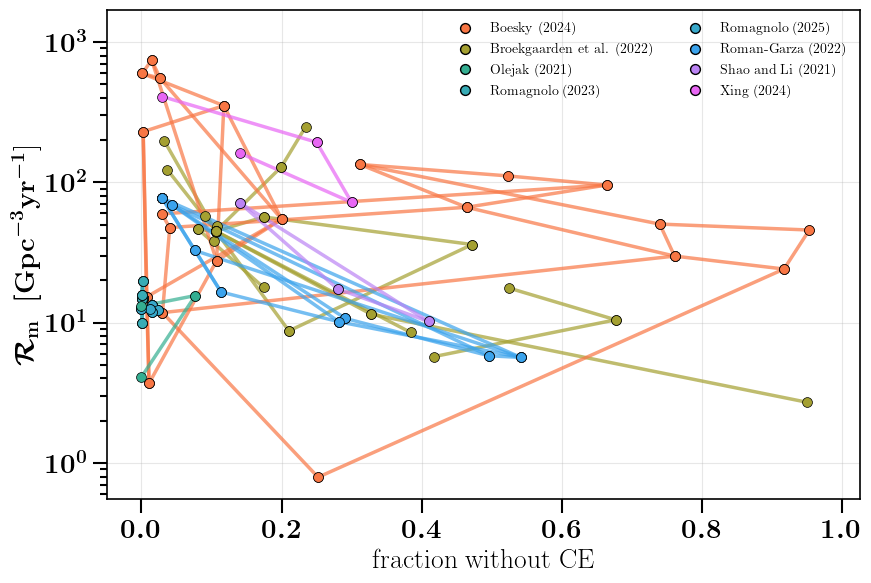

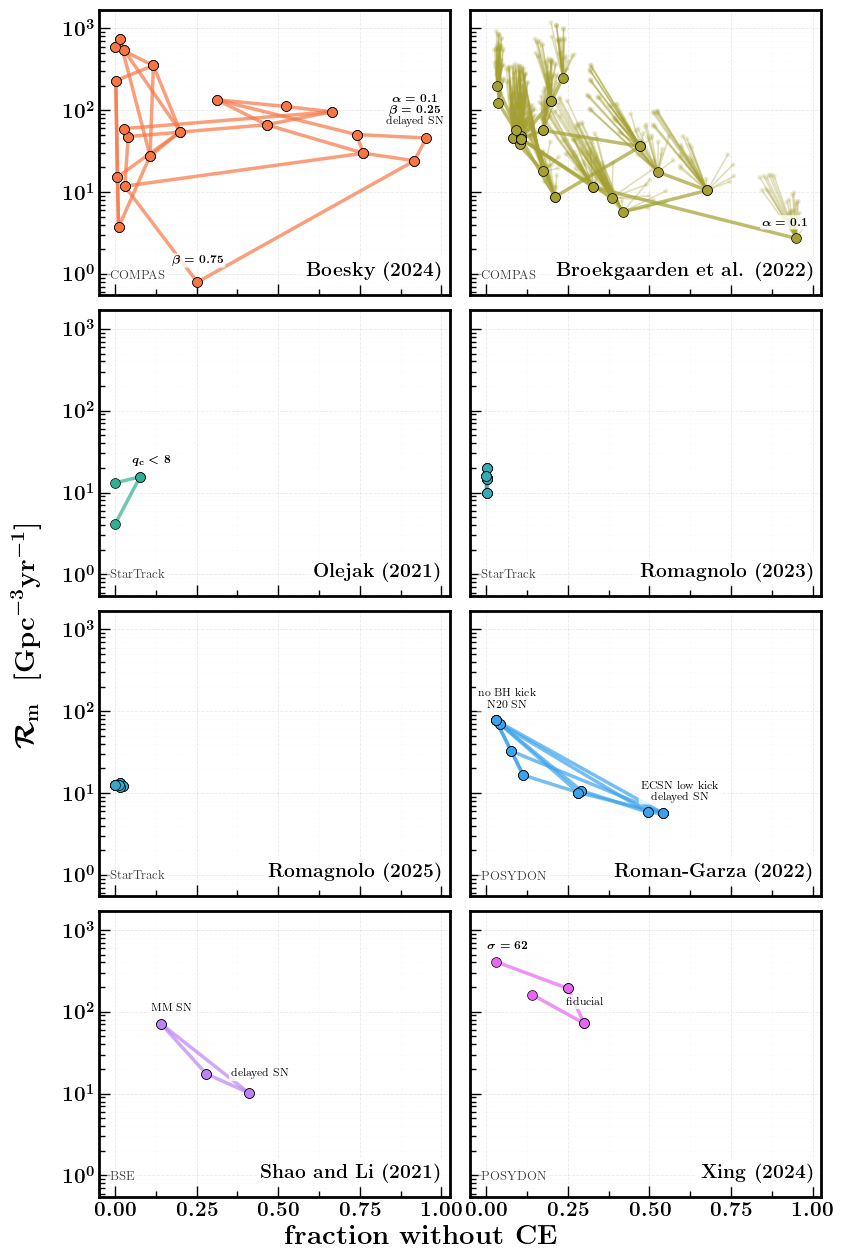


Running for NS-NS
Saving figures to: /Users/floorbroekgaarden/Projects/GitHub/Rates_of_Formation_Channels/plottingCode/All_Figures/
Looking for Broekgaarden SFRD file at: /Users/floorbroekgaarden/Projects/GitHub/Rates_of_Formation_Channels/plottingCode/All_Figures/Data_formation_channels_intrinsic/extra_fc_rates/Broekgaarden_NSNS_all_SFRD_variations_combined.csv
Exists? True
Loaded Broekgaarden SFRD rows: 560
Columns: ['DCOlabel', 'SFRD_variation', 'source_file', 'model_name', 'total_rate', 'without_CE_fraction', 'with_CE_fraction', 'sum_CE_fractions', 'sum_minus_one', 'fractions_sum_to_one']
Using broek_legend = 'Broekgaarden et al. (2022)'
Using vanSon_legend = 'van Son (2023) '
Using vanSon_fiducial_model = 'van Son (2023) '
Using broek_legend = 'Broekgaarden et al. (2022)'

--- plot_broekgaarden_secondary_sfrd ---
legend_for_color = 'Broekgaarden et al. (2022)'
broek_legend     = 'Broekgaarden et al. (2022)'
Broekgaarden extra points plotted: 560
Saved big plot to: /Users/floorbro

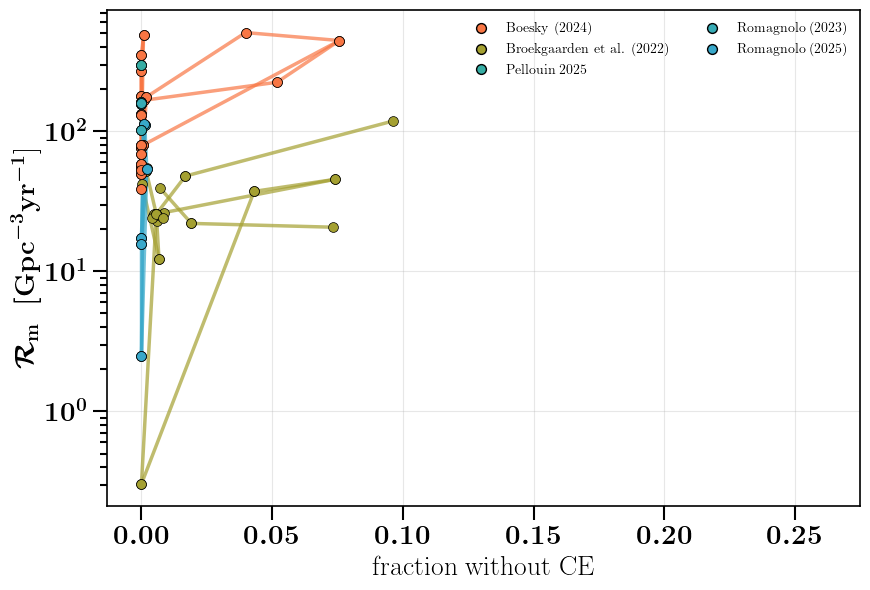

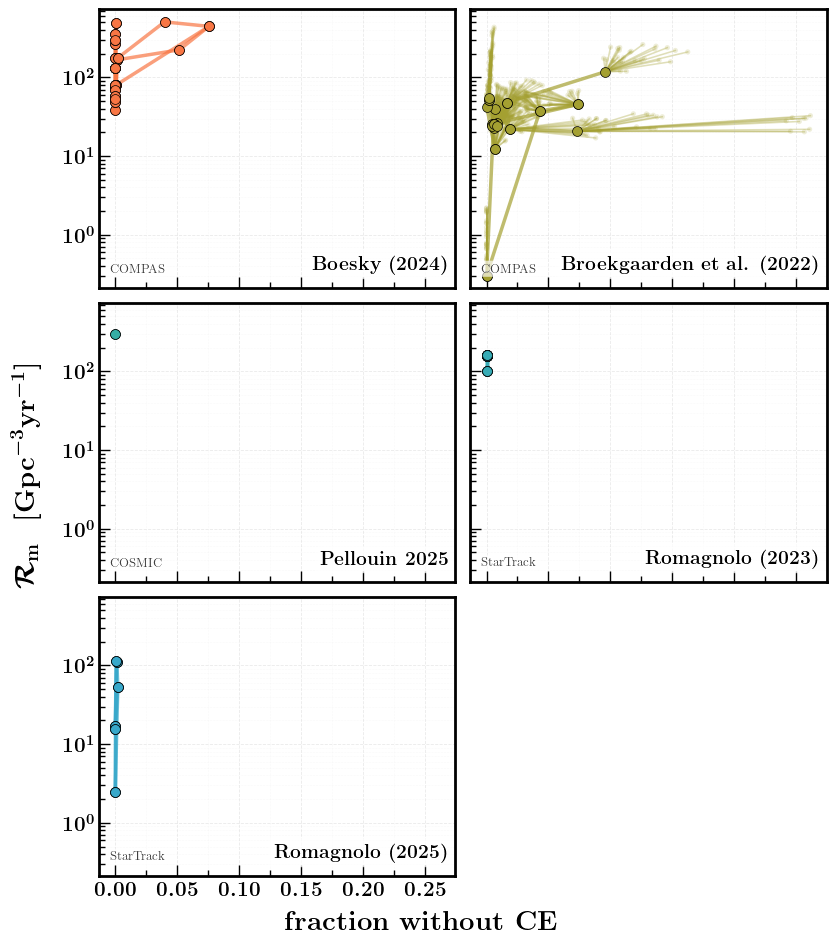

(<Figure size 900x600 with 1 Axes>,
 <Axes: xlabel='fraction without CE', ylabel='$\\mathcal{R}_{\\rm{m}}$ \\  $[\\rm{Gpc}^{-3} \\rm{yr}^{-1}$]'>,
 <Figure size 840x960 with 6 Axes>,
 array([[<Axes: >, <Axes: >],
        [<Axes: >, <Axes: >],
        [<Axes: >, <Axes: >]], dtype=object))

In [4]:
# for dco in ["BH-BH", "BH-NS", "NS-NS"]:
BBH_annotate  = ["Li25-i", "Olejak21-M480 (changedCEcriteria)", "Olejak21-M480 (changedCEcriteria)", "Olejak21-M380 (fiducial)", "Olejak21-M481 (changedCEcriteria+switch)", "B21-qcrit-Claeys", "Boesky_sigma_750_RMP_M",\
                 "B22-G-alpha0-1", "DT22-M11", "DT22-M6", "B21-eddington-1E9", "Boesky_alphaCE_0_1_beta0_75","ShaoLi_stochastic ", "ShaoLi_delayed", "RG21-noBH-kick-SN:delayed", "RG21-ECSN:Full-SN:delayed", "B22-K-optimisticCE"]
make_withoutCE_plots("BH-BH", x_quantity="fraction", annotate_models=BBH_annotate)


BHNS_annotate = ["B22-G-alpha0-1", "ShaoLi_delayed", "ShaoLi_stochastic ", "Boesky_alphaCE_0_1_beta0_25", "Boesky_alphaCE_0_1_beta0_75", "Olejak21-M480 (changedCEcriteria)",\
                "RG21-SN:delayed", "RG21-noBHkick-SN:N20", "Xing24_fiducial", "Xing24_sigma_61_6"] 
make_withoutCE_plots(DCOlabel="BH-NS", ncols_grid=2, x_quantity="fraction", annotate_models=BHNS_annotate)


make_withoutCE_plots(DCOlabel="NS-NS", ncols_grid=2, x_quantity="fraction")



# Interactive plots html 



In [5]:
# --- Required imports (add these at the top of your notebook/script) ---
import os
import math
import re
import numpy as np
import pandas as pd

import plotly.graph_objects as go
from plotly.subplots import make_subplots

import seaborn as sns

from typing import Optional


def plot_withoutCE_by_study_plotly(
    path_to_file: str,
    DCOlabel: str = "BH-BH",
    relation_file: Optional[str] = None,
    rates_file: Optional[str] = None,
    specs_file: str = "simulation_specs.csv",
    ncols_grid: int = 4,
    panel_w: float = 360,   # pixels per panel (width)
    panel_h: float = 290,   # pixels per panel (height)
    marker_size: int = 9,
    line_width: float = 2.5,
    line_alpha: float = 0.75,
    palette_name: str = "husl",  # seaborn palette
):
    """
    Plotly (non-FigureWidget) version of the *grid by study* plot with:
      - log10 y-axis
      - shared x/y limits across panels
      - hover text on points
      - hover text on lines via invisible midpoint markers (no visual kinks)
      - dropdown toggle by "parameter families" inferred from travel_label
      - HTML export via fig.write_html(...)

    Returns:
      - plotly.graph_objects.Figure
    """

#     # ---------- helper: parameter family inferred from travel_label ----------
#     def parameter_family_from_travel_label(travel_label: str) -> str:
#         s = str(travel_label).strip()
#         if (not s) or (s.lower() == "nan"):
#             return "unknown"

#         # remove LaTeX $...$ delimiters
#         s = s.replace("$", "").strip()

#         # remove arrow tokens
#         s = s.replace(r"\uparrow", "").replace(r"\downarrow", "")
#         s = s.replace("↑", "").replace("↓", "")

#         # normalize spaces
#         s = re.sub(r"\s+", " ", s).strip()
#         return s if s else "unknown"

    # ---------- load relations ----------
    if relation_file is None:
        relation_file = f"{DCOlabel}_fcRelations.csv"
    df_rel = pd.read_csv(os.path.join(path_to_file, relation_file))

    # ---------- load rates ----------
    if rates_file is None:
        rates_file = f"{DCOlabel}_rates_review.csv"
    df_rates = pd.read_csv(os.path.join(path_to_file, rates_file)).fillna(0.0)
    if "model" not in df_rates.columns:
        raise ValueError("Rates file must include a 'model' column.")
    df_rates = df_rates.set_index("model")
    
    
    # ---------- load extra van Son (2023) S(Z,z) variations ----------
    extra_sfrd_file = os.path.join(path_to_file, "extra_fc_rates", "vanSon2023_sfrd.csv")
    if os.path.exists(extra_sfrd_file):
        df_rates_vanson_sfrd = pd.read_csv(extra_sfrd_file).fillna(0.0).set_index("model")
    else:
        df_rates_vanson_sfrd = None

    vanSon_legend = "van Son (2023) "
    vanSon_fiducial_model = "van Son (2023) "

    # ---------- infer y-column header via obtain_fc_dict ----------
    fc_dict = obtain_fc_dict()
    fc_total_header = fc_dict["total"]["name"]      # column name for total intrinsic rate
    yname = r"Total Merger Rate [Gpc3/yr]" #"[Gpc$^{-3}$ yr$^{-1}$] " # [Gpc$^{-3}$ yr$^{-1}$]" #fc_dict["total"]["axlabel"]

    channels = fc_dict["CE_simple"]["channels"]
    channel_dict = next(ch for ch in channels if ch["name"] == "fraction without common envelope")
    xname = channel_dict["axlabel"]

    if fc_total_header not in df_rates.columns:
        raise ValueError(
            f"Could not find total-rate column '{fc_total_header}' in rates file. "
            f"Available columns: {list(df_rates.columns)}"
        )
    if "fraction without common envelope" not in df_rates.columns:
        raise ValueError("Rates file must include column 'fraction without common envelope'.")

    # ---------- load simulation specs for point hover labels ----------
    specs_path = os.path.join(path_to_file, specs_file)
    if not os.path.exists(specs_path):
        raise FileNotFoundError(f"Could not find simulation specs file: {specs_path}")

    df_specs = pd.read_csv(specs_path)
    if "model" not in df_specs.columns:
        raise ValueError("simulation_specs.csv must include a 'model' column.")
    df_specs = df_specs.set_index("model")
    
    if "using" not in df_rel.columns:
        raise ValueError(f"{relation_file} must include a 'using' column for family dropdowns.")
    

    label_cols = [c for c in ["label_1", "label_2", "label_3", "label_4"] if c in df_specs.columns]

    # ---------- global axis limits (shared across all panels) ----------
    xvals = df_rates["fraction without common envelope"].astype(float).values
    yvals = df_rates[fc_total_header].astype(float).values

    # Remove non-positive values for log scale safety
    yvals_pos = yvals[yvals > 0]
    if len(yvals_pos) == 0:
        raise ValueError("All y-values are non-positive; cannot use log axis.")

    xmin, xmax = np.nanmin(xvals), np.nanmax(xvals)
    ymin, ymax = np.nanmin(yvals_pos), np.nanmax(yvals_pos)

    # Add small padding so points are not on edges
    xpad = 0.02 * (xmax - xmin) if xmax > xmin else 0.05
    xmin -= xpad
    xmax += xpad

    # log padding in multiplicative space
    ymin /= 1.2
    ymax *= 1.2

    def point_hover_text(model: str) -> str:
        """Build hover text for a point using label_1..label_4 (only non-empty)."""
        lines = [f"<b>{model}</b>"]
        if model in df_specs.index and label_cols:
            vals = []
            for c in label_cols:
                v = df_specs.loc[model, c]
                if pd.notna(v):
                    s = str(v).strip()
                    if s and s.lower() != "nan":
                        vals.append(s)
            if vals:
                lines.append("<br>".join(vals))
        return "<br>".join(lines)

    def line_hover_text(row: pd.Series) -> str:
        tl = str(row.get("travel_label", "")).strip()
        fo = str(row.get("from_option", "")).strip()
        to = str(row.get("to_option", "")).strip()
        return f"change: {tl}: from {fo} to {to}"
    
    
    def add_vanSon2023_sfrd_overlay(fig, leg, row_i, col_i, color_map):
        """
        Add extra van Son (2023) S(Z,z) variation points/lines to the van Son panel only.
        """
        if df_rates_vanson_sfrd is None:
            return
        if str(leg).strip() != str(vanSon_legend).strip():
            return
        if vanSon_fiducial_model not in df_rates.index:
            return

        x_fid = float(df_rates.loc[vanSon_fiducial_model, "fraction without common envelope"])
        y_fid = float(df_rates.loc[vanSon_fiducial_model, fc_total_header])

        if y_fid <= 0:
            return

        this_color = color_map[leg]

        for model in df_rates_vanson_sfrd.index:
            # skip duplicate fiducial row in extra file, if present
            if "fiducial" in str(model).strip().lower():
                continue

            x = float(df_rates_vanson_sfrd.loc[model, "fraction without common envelope"])
            y = float(df_rates_vanson_sfrd.loc[model, fc_total_header])

            if y <= 0:
                continue

            hover_txt = (
                f"<b>{leg.strip()}</b><br>"
                f"S(Z,z) variation<br>"
                f"{model}<br>"
                f"connected to fiducial"
            )

            # midpoint for hover on log-y axis
            mx = 0.5 * (x_fid + x)
            my = 10 ** (0.5 * (np.log10(y_fid) + np.log10(y)))

            # background line
            fig.add_trace(
                go.Scatter(
                    x=[x_fid, x],
                    y=[y_fid, y],
                    mode="lines",
                    line=dict(width=line_width * 0.9, color=this_color),
                    opacity=0.35,
                    hoverinfo="skip",
                    showlegend=False,
                    meta=dict(kind="line", family="S(Z,z) variations", study=str(leg)),
                ),
                row=row_i,
                col=col_i,
            )

            # visible point
            fig.add_trace(
                go.Scatter(
                    x=[x],
                    y=[y],
                    mode="markers",
                    marker=dict(
                        size=max(6, marker_size - 1),
                        color=this_color,
                        line=dict(width=0.0, color=this_color),
                        opacity=0.75,
                    ),
                    hovertemplate=f"{hover_txt}<extra></extra>",
                    showlegend=False,
                    meta=dict(kind="point", study=str(leg)),
                ),
                row=row_i,
                col=col_i,
            )

            # invisible hover marker for the connecting line
            fig.add_trace(
                go.Scatter(
                    x=[mx],
                    y=[my],
                    mode="markers",
                    marker=dict(size=16, opacity=0.0),
                    text=[hover_txt],
                    hovertemplate="%{text}<extra></extra>",
                    hoverinfo="text",
                    showlegend=False,
                    meta=dict(kind="hover", family="S(Z,z) variations", study=str(leg)),
                ),
                row=row_i,
                col=col_i,
            )

    # ---------- studies + colors ----------
    legends_sorted = sorted(df_rel["legend"].dropna().unique().tolist())
    n_studies = len(legends_sorted)

    ncols = int(ncols_grid)
    nrows = int(math.ceil(n_studies / ncols))

    palette = sns.color_palette(palette_name, n_studies)

    def to_rgb_str(rgb_tuple):
        r, g, b = [int(round(255 * x)) for x in rgb_tuple]
        return f"rgb({r},{g},{b})"

    color_map = {leg: to_rgb_str(palette[i]) for i, leg in enumerate(legends_sorted)}

    # ---------- make subplot figure ----------
    fig = make_subplots(
        rows=nrows,
        cols=ncols,
        subplot_titles=legends_sorted,
        shared_xaxes=True,
        shared_yaxes=True,
        horizontal_spacing=0.02,
        vertical_spacing=0.1,
    )

    # ---------- add traces per study ----------
    for i, leg in enumerate(legends_sorted):
        row_i = i // ncols + 1
        col_i = i % ncols + 1

        df_sub = df_rel[df_rel["legend"] == leg].copy()

        # Collect unique models used in this study (for point trace)
        models = pd.unique(df_sub[["from_modelname", "to_modelname"]].values.ravel("K"))
        models = [m for m in models if isinstance(m, str) and m in df_rates.index]

        xs, ys, hovers = [], [], []
        for m in models:
            xs.append(float(df_rates.loc[m, "fraction without common envelope"]))
            ys.append(float(df_rates.loc[m, fc_total_header]))
            hovers.append(point_hover_text(m))

        # Points (one trace per panel)
        fig.add_trace(
            go.Scatter(
                x=xs,
                y=ys,
                mode="markers",
                marker=dict(
                    size=marker_size,
                    color=color_map[leg],
                    line=dict(width=0.8, color="black"),
                    opacity=1.0,
                ),
                hovertemplate="%{text}<extra></extra>",
                text=hovers,
                showlegend=False,
                meta=dict(kind="point", study=str(leg)),
            ),
            row=row_i,
            col=col_i,
        )

        # Lines + invisible hover markers (hover text without FigureWidget callbacks)
        for _, rr in df_sub.iterrows():
            m_from = rr.get("from_modelname", None)
            m_to = rr.get("to_modelname", None)

            if not (isinstance(m_from, str) and isinstance(m_to, str)):
                continue
            if m_from not in df_rates.index or m_to not in df_rates.index:
                continue

            x1 = float(df_rates.loc[m_from, "fraction without common envelope"])
            y1 = float(df_rates.loc[m_from, fc_total_header])
            x2 = float(df_rates.loc[m_to, "fraction without common envelope"])
            y2 = float(df_rates.loc[m_to, fc_total_header])

            # skip non-positive y (log safety)
            if y1 <= 0 or y2 <= 0:
                continue

            hover_txt = line_hover_text(rr)

#             m_from_using = ""
#             m_to_using = ""

#             if m_from in df_specs.index and "using" in df_specs.columns:
#                 m_from_using = str(df_specs.loc[m_from, "using"]).strip()

#             if m_to in df_specs.index and "using" in df_specs.columns:
#                 m_to_using = str(df_specs.loc[m_to, "using"]).strip()

#             # Usually the varied model is the "to" model, so prefer that.
#             family = m_to_using if m_to_using and m_to_using.lower() != "nan" else m_from_using

#             if not family or family.lower() == "nan":
#                 family = "unknown"
            family = str(rr.get("using", "")).strip()

            if not family or family.lower() == "nan":
                family = "unknown"  

            # Midpoint for log-y axis: geometric mean keeps straightness
            mx = 0.5 * (x1 + x2)
            my = 10 ** (0.5 * (np.log10(y1) + np.log10(y2)))

            # 1) Draw straight line (no hover)
            fig.add_trace(
                go.Scatter(
                    x=[x1, x2],
                    y=[y1, y2],
                    mode="lines",
                    line=dict(width=line_width, color=color_map[leg]),
                    opacity=line_alpha,
                    hoverinfo="skip",
                    showlegend=False,
                    meta=dict(kind="line", family=family, study=str(leg)),
                ),
                row=row_i,
                col=col_i,
            )

            # 2) Invisible hover marker at midpoint (drives the hover text)
            fig.add_trace(
                go.Scatter(
                    x=[mx],
                    y=[my],
                    mode="markers",
                    marker=dict(size=16, opacity=0.0),
                    text=[hover_txt],
                    hovertemplate="%{text}<extra></extra>",
                    hoverinfo="text",
                    showlegend=False,
                    meta=dict(kind="hover", family=family, study=str(leg)),
                ),
                row=row_i,
                col=col_i,
            )
            
        # Add van Son (2023) extra S(Z,z) variations in the van Son panel
        add_vanSon2023_sfrd_overlay(fig, leg, row_i, col_i, color_map)

        # Axes per panel
        fig.update_xaxes(type="linear", range=[xmin, xmax], row=row_i, col=col_i)
        fig.update_yaxes(type="log", range=[np.log10(ymin), np.log10(ymax)], row=row_i, col=col_i)

    # Turn off unused panels
    for j in range(n_studies, nrows * ncols):
        r = j // ncols + 1
        c = j % ncols + 1
        fig.update_xaxes(visible=False, row=r, col=c)
        fig.update_yaxes(visible=False, row=r, col=c)

    # Layout
    fig.update_layout(
        width=int(panel_w * ncols),
        height=int(panel_h * nrows) + 80,
        margin=dict(l=70, r=160, t=70, b=70),
        hovermode="closest",
        hoverdistance=40,
    )

    # Add x-label to every subplot
    for r in range(1, nrows + 1):
        for c in range(1, ncols + 1):
            # Skip unused panels
            idx = (r - 1) * ncols + (c - 1)
            if idx >= n_studies:
                continue

            fig.update_xaxes(
                title_text=f"<b>{xname}</b>",
                row=r,
                col=c
            )
            
    # Add y-label to every subplot
    for r in range(1, nrows + 1):
        for c in range(1, ncols + 1):
            # Skip unused panels
            idx = (r - 1) * ncols + (c - 1)
            if c == 1:  # only first column:
                fig.update_yaxes(
                    title_text=yname,
                    row=r,
                    col=c
                )

    # Subplot title styling
    fig.update_annotations(font=dict(size=14))

    # ---------- Dropdown: Toggle parameter families ----------
    families = set()
    for tr in fig.data:
        meta = getattr(tr, "meta", None) or {}
        if meta.get("kind") in ("line", "hover"):
            families.add(meta.get("family", "unknown"))
    families = sorted(families)

    def visibility_for_family(fam: Optional[str]):
        """fam=None shows all; else show only traces for that family. Points always visible."""
        vis = []
        for tr in fig.data:
            meta = getattr(tr, "meta", None) or {}
            kind = meta.get("kind", None)
            if kind == "point" or kind is None:
                vis.append(True)
            elif kind in ("line", "hover"):
                vis.append(True if fam is None else (meta.get("family") == fam))
            else:
                vis.append(True)
        return vis

    buttons = [dict(label="All families", method="update", args=[{"visible": visibility_for_family(None)}])]
    for fam in families:
        buttons.append(dict(label=str(fam), method="update", args=[{"visible": visibility_for_family(fam)}]))

    fig.update_layout(
        updatemenus=[
            dict(
                type="dropdown",
                x=1.02,
                y=1.02,
                xanchor="left",
                yanchor="top",
                buttons=buttons,
            )
        ]
    )

    return fig




# BH-BH 

In [6]:
# ---- Example usage ----
DCOlabel = "BH-BH"

fig = plot_withoutCE_by_study_plotly(
    path_to_file=path_to_file,
    DCOlabel="BH-BH",
    ncols_grid=5,
    palette_name="husl",
    specs_file="simulation_specs.csv",
)

out = 'Output_Figures/Fig6_' +  "BH-BH_by_study_interactive.html"
fig.write_html(out, include_plotlyjs=True, full_html=True)
print("Wrote:", out)

# In a notebook, this will open a new browser tab (no nbformat needed)
import webbrowser, os
webbrowser.open("file://" + os.path.abspath(out))

Wrote: Output_Figures/Fig6_BH-BH_by_study_interactive.html


True

# BH-NS 

In [7]:
# ---- Example usage ----
DCOlabel = "BH-NS"

fig = plot_withoutCE_by_study_plotly(
    path_to_file=path_to_file,
    DCOlabel=DCOlabel,
    ncols_grid=4,
    palette_name="husl",
    specs_file="simulation_specs.csv",
)

out = 'Output_Figures/Fig7_' +  DCOlabel + "_by_study_interactive.html"
fig.write_html(out, include_plotlyjs=True, full_html=True)
print("Wrote:", out)

# In a notebook, this will open a new browser tab (no nbformat needed)
import webbrowser, os
webbrowser.open("file://" + os.path.abspath(out))

Wrote: Output_Figures/Fig7_BH-NS_by_study_interactive.html


True

# NS-NS 

In [8]:
# ---- Example usage ----
DCOlabel = "NS-NS"

fig = plot_withoutCE_by_study_plotly(
    path_to_file=path_to_file,
    DCOlabel=DCOlabel,
    ncols_grid=5,
    palette_name="husl",
    specs_file="simulation_specs.csv",
)

out = 'Output_Figures/Fig8_' +  DCOlabel + "_by_study_interactive.html"
fig.write_html(out, include_plotlyjs=True, full_html=True)
print("Wrote:", out)

# In a notebook, this will open a new browser tab (no nbformat needed)
import webbrowser, os
webbrowser.open("file://" + os.path.abspath(out))

Wrote: Output_Figures/Fig8_NS-NS_by_study_interactive.html


True

In [9]:
## make extra interactive figures that show absolute rates


In [10]:
# --- Required imports ---
import os
import math
import re
import numpy as np
import pandas as pd

import plotly.graph_objects as go
from plotly.subplots import make_subplots

import seaborn as sns
from typing import Optional


def plot_ce_vs_withoutce_rate_by_study_plotly(
    path_to_file: str,
    DCOlabel: str = "BH-BH",
    relation_file: Optional[str] = None,
    rates_file: Optional[str] = None,
    specs_file: str = "simulation_specs.csv",
    ncols_grid: int = 4,
    panel_w: float = 360,   # pixels per panel
    panel_h: float = 290,   # pixels per panel
    marker_size: int = 9,
    line_width: float = 2.5,
    line_alpha: float = 0.75,
    palette_name: str = "husl",
    add_dropdown: bool = True,
):
    """
    Plotly grid-by-study plot where:
      x = rate without CE = (fraction without CE) * total rate
      y = rate with CE    = (fraction with CE)    * total rate

    Both axes are logarithmic.

    Returns
    -------
    plotly.graph_objects.Figure
    """

    # ---------- helper: parameter family inferred from travel_label ----------
    def parameter_family_from_travel_label(travel_label: str) -> str:
        s = str(travel_label).strip()
        if (not s) or (s.lower() == "nan"):
            return "unknown"

        s = s.replace("$", "").strip()
        s = s.replace(r"\uparrow", "").replace(r"\downarrow", "")
        s = s.replace("↑", "").replace("↓", "")
        s = re.sub(r"\s+", " ", s).strip()
        return s if s else "unknown"

    # ---------- load relations ----------
    if relation_file is None:
        relation_file = f"{DCOlabel}_fcRelations.csv"
    df_rel = pd.read_csv(os.path.join(path_to_file, relation_file))

    # ---------- load rates ----------
    if rates_file is None:
        rates_file = f"{DCOlabel}_rates_review.csv"
    df_rates = pd.read_csv(os.path.join(path_to_file, rates_file)).fillna(0.0)

    if "model" not in df_rates.columns:
        raise ValueError("Rates file must include a 'model' column.")
    df_rates = df_rates.set_index("model")

    # ---------- infer total-rate column from obtain_fc_dict ----------
    fc_dict = obtain_fc_dict()
    fc_total_header = fc_dict["total"]["name"]

    required_cols = [
        "fraction without common envelope",
        "fraction with common envelope",
        fc_total_header,
    ]
    missing = [c for c in required_cols if c not in df_rates.columns]
    if missing:
        raise ValueError(f"Missing required columns in rates file: {missing}")

    # ---------- load simulation specs for hover labels ----------
    specs_path = os.path.join(path_to_file, specs_file)
    if not os.path.exists(specs_path):
        raise FileNotFoundError(f"Could not find simulation specs file: {specs_path}")

    df_specs = pd.read_csv(specs_path)
    if "model" not in df_specs.columns:
        raise ValueError("simulation_specs.csv must include a 'model' column.")
    df_specs = df_specs.set_index("model")

    label_cols = [c for c in ["label_1", "label_2", "label_3", "label_4"] if c in df_specs.columns]

    # ---------- define derived rate coordinates ----------
    total_rate = df_rates[fc_total_header].astype(float)
    frac_without = df_rates["fraction without common envelope"].astype(float)
    frac_with = df_rates["fraction with common envelope"].astype(float)

    df_rates["rate_without_CE"] = frac_without * total_rate
    df_rates["rate_with_CE"] = frac_with * total_rate

    xcol = "rate_without_CE"
    ycol = "rate_with_CE"

    xname = r"without CE rate [Gpc-3/yr]"
    yname = r"with CE rate [Gpc-3/yr]"

    # ---------- global axis limits ----------
    xvals = df_rates[xcol].astype(float).values
    yvals = df_rates[ycol].astype(float).values

    # Keep only positive values for log axes
    xvals_pos = xvals[np.isfinite(xvals) & (xvals > 0)]
    yvals_pos = yvals[np.isfinite(yvals) & (yvals > 0)]

    if len(xvals_pos) == 0:
        raise ValueError("All x-values are non-positive; cannot use log x-axis.")
    if len(yvals_pos) == 0:
        raise ValueError("All y-values are non-positive; cannot use log y-axis.")

    xmin, xmax = np.nanmin(xvals_pos), np.nanmax(xvals_pos)
    ymin, ymax = np.nanmin(yvals_pos), np.nanmax(yvals_pos)

    # multiplicative padding for log axes
    xmin /= 1.25
    xmax *= 1.25
    ymin /= 1.25
    ymax *= 1.25

    # ---------- hover helpers ----------
    def point_hover_text(model: str) -> str:
        lines = [f"<b>{model}</b>"]

        if model in df_specs.index and label_cols:
            vals = []
            for c in label_cols:
                v = df_specs.loc[model, c]
                if pd.notna(v):
                    s = str(v).strip()
                    if s and s.lower() != "nan":
                        vals.append(s)
            if vals:
                lines.append("<br>".join(vals))

        if model in df_rates.index:
            x = df_rates.loc[model, xcol]
            y = df_rates.loc[model, ycol]
            rtot = df_rates.loc[model, fc_total_header]
            fwo = df_rates.loc[model, "fraction without common envelope"]
            fwi = df_rates.loc[model, "fraction with common envelope"]

            lines.append(
                f"<br>"
                f"R_without CE = {x:.3e}<br>"
                f"R_with CE = {y:.3e}<br>"
                f"R_total = {rtot:.3e}<br>"
                f"f_without CE = {fwo:.3f}<br>"
                f"f_with CE = {fwi:.3f}"
            )

        return "<br>".join(lines)

    def line_hover_text(row: pd.Series, m_from: str, m_to: str) -> str:
        tl = str(row.get("travel_label", "")).strip()
        fo = str(row.get("from_option", "")).strip()
        to = str(row.get("to_option", "")).strip()
        return (
            f"<b>{m_from}</b> → <b>{m_to}</b><br>"
            f"change: {tl}: from {fo} to {to}"
        )

    # ---------- studies + colors ----------
    legends_sorted = sorted(df_rel["legend"].dropna().unique().tolist())
    n_studies = len(legends_sorted)

    ncols = int(ncols_grid)
    nrows = int(math.ceil(n_studies / ncols))

    palette = sns.color_palette(palette_name, n_studies)

    def to_rgb_str(rgb_tuple):
        r, g, b = [int(round(255 * x)) for x in rgb_tuple]
        return f"rgb({r},{g},{b})"

    color_map = {leg: to_rgb_str(palette[i]) for i, leg in enumerate(legends_sorted)}

    # ---------- make subplot figure ----------
    fig = make_subplots(
        rows=nrows,
        cols=ncols,
        subplot_titles=legends_sorted,
        shared_xaxes=True,
        shared_yaxes=True,
        horizontal_spacing=0.02,
        vertical_spacing=0.10,
    )

    # ---------- add traces per study ----------
    for i, leg in enumerate(legends_sorted):
        row_i = i // ncols + 1
        col_i = i % ncols + 1

        df_sub = df_rel[df_rel["legend"] == leg].copy()

        # --- collect unique models for this panel ---
        models = pd.unique(df_sub[["from_modelname", "to_modelname"]].values.ravel("K"))
        models = [m for m in models if isinstance(m, str) and m in df_rates.index]

        xs, ys, hovers = [], [], []
        for m in models:
            x = float(df_rates.loc[m, xcol])
            y = float(df_rates.loc[m, ycol])

            # log-axis safety
            if (not np.isfinite(x)) or (not np.isfinite(y)) or x <= 0 or y <= 0:
                continue

            xs.append(x)
            ys.append(y)
            hovers.append(point_hover_text(m))

        # points
        fig.add_trace(
            go.Scatter(
                x=xs,
                y=ys,
                mode="markers",
                marker=dict(
                    size=marker_size,
                    color=color_map[leg],
                    line=dict(width=0.8, color="black"),
                    opacity=1.0,
                ),
                hovertemplate="%{text}<extra></extra>",
                text=hovers,
                showlegend=False,
                meta=dict(kind="point", study=str(leg)),
            ),
            row=row_i,
            col=col_i,
        )

        # lines + invisible midpoint hover markers
        for _, rr in df_sub.iterrows():
            m_from = rr.get("from_modelname", None)
            m_to = rr.get("to_modelname", None)

            if not (isinstance(m_from, str) and isinstance(m_to, str)):
                continue
            if m_from not in df_rates.index or m_to not in df_rates.index:
                continue

            x1 = float(df_rates.loc[m_from, xcol])
            y1 = float(df_rates.loc[m_from, ycol])
            x2 = float(df_rates.loc[m_to, xcol])
            y2 = float(df_rates.loc[m_to, ycol])

            # log safety
            if (
                (not np.isfinite(x1)) or (not np.isfinite(y1)) or
                (not np.isfinite(x2)) or (not np.isfinite(y2)) or
                x1 <= 0 or y1 <= 0 or x2 <= 0 or y2 <= 0
            ):
                continue

            hover_txt = line_hover_text(rr, m_from, m_to)
            family = parameter_family_from_travel_label(rr.get("travel_label", ""))

            # midpoint in log-log space
            mx = 10 ** (0.5 * (np.log10(x1) + np.log10(x2)))
            my = 10 ** (0.5 * (np.log10(y1) + np.log10(y2)))

            # visible line
            fig.add_trace(
                go.Scatter(
                    x=[x1, x2],
                    y=[y1, y2],
                    mode="lines",
                    line=dict(width=line_width, color=color_map[leg]),
                    opacity=line_alpha,
                    hoverinfo="skip",
                    showlegend=False,
                    meta=dict(kind="line", family=family, study=str(leg)),
                ),
                row=row_i,
                col=col_i,
            )

            # invisible hover marker
            fig.add_trace(
                go.Scatter(
                    x=[mx],
                    y=[my],
                    mode="markers",
                    marker=dict(size=16, opacity=0.0),
                    text=[hover_txt],
                    hovertemplate="%{text}<extra></extra>",
                    hoverinfo="text",
                    showlegend=False,
                    meta=dict(kind="hover", family=family, study=str(leg)),
                ),
                row=row_i,
                col=col_i,
            )

        # axes per panel
        fig.update_xaxes(
            type="log",
            range=[np.log10(xmin), np.log10(xmax)],
            row=row_i,
            col=col_i
        )
        fig.update_yaxes(
            type="log",
            range=[np.log10(ymin), np.log10(ymax)],
            row=row_i,
            col=col_i
        )
        
        
        
        # --- Add diagonal 1:1 line (R_withCE = R_withoutCE) ---
        # Use global limits so all panels share the same reference
        diag_min = max(xmin, ymin)
        diag_max = min(xmax, ymax)

        if diag_min > 0 and diag_max > diag_min:
            fig.add_trace(
                go.Scatter(
                    x=[diag_min, diag_max],
                    y=[diag_min, diag_max],
                    mode="lines",
                    line=dict(
                        color="black",
                        width=1.5,
                        dash="dash"
                    ),
                    opacity=0.7,
                    hoverinfo="skip",
                    showlegend=False,
                    meta=dict(kind="reference"),
                ),
                row=row_i,
                col=col_i,
            )        
    
    
#         # --- Add annotations: CE-dominated / SMT-dominated ---
#         # Place them relative to axis limits (log-safe positioning)

#         # --- Add annotations: CE-dominated / SMT-dominated ---
#         # Use explicit subplot axis references instead of row/col
#         axis_index = i + 1
#         xref = f"x{axis_index}" if axis_index > 1 else "x"
#         yref = f"y{axis_index}" if axis_index > 1 else "y"

#         x_ce  = 10 ** (0.70 * np.log10(xmin) + 0.30 * np.log10(xmax))
#         y_ce  = 10 ** (0.30 * np.log10(ymin) + 0.70 * np.log10(ymax))

#         x_smt = 10 ** (0.30 * np.log10(xmin) + 0.70 * np.log10(xmax))
#         y_smt = 10 ** (0.70 * np.log10(ymin) + 0.30 * np.log10(ymax))

#         fig.add_annotation(
#             x=x_ce,
#             y=y_ce,
#             xref=xref,
#             yref=yref,
#             text="CE-dominated",
#             showarrow=False,
#             font=dict(size=10, color="rgba(0,0,0,0.55)"),
#             align="left",
#             bgcolor="rgba(255,255,255,0.35)",
#             borderpad=2,
#             xanchor="left",
#             yanchor="bottom",
#         )

#         fig.add_annotation(
#             x=x_smt,
#             y=y_smt,
#             xref=xref,
#             yref=yref,
#             text="SMT-dominated",
#             showarrow=False,
#             font=dict(size=10, color="rgba(0,0,0,0.55)"),
#             align="right",
#             bgcolor="rgba(255,255,255,0.35)",
#             borderpad=2,
#             xanchor="right",
#             yanchor="top",
#         )
    
    

    # ---------- turn off unused panels ----------
    for j in range(n_studies, nrows * ncols):
        r = j // ncols + 1
        c = j % ncols + 1
        fig.update_xaxes(visible=False, row=r, col=c)
        fig.update_yaxes(visible=False, row=r, col=c)

    # ---------- layout ----------
    fig.update_layout(
        width=int(panel_w * ncols),
        height=int(panel_h * nrows) + 80,
        margin=dict(l=70, r=160 if add_dropdown else 40, t=70, b=70),
        hovermode="closest",
        hoverdistance=40,
    )

    # ---------- x-labels on every used subplot ----------
    for r in range(1, nrows + 1):
        for c in range(1, ncols + 1):
            idx = (r - 1) * ncols + (c - 1)
            if idx >= n_studies:
                continue

            fig.update_xaxes(
                title_text=f"<b>{xname}</b>",
                row=r,
                col=c
            )

    # ---------- y-labels only on first column ----------
    for r in range(1, nrows + 1):
        for c in range(1, ncols + 1):
            idx = (r - 1) * ncols + (c - 1)
            if idx >= n_studies:
                continue
            if c == 1:
                fig.update_yaxes(
                    title_text=yname,
                    row=r,
                    col=c
                )

    # subplot title styling
#     fig.update_annotations(font=dict(size=14))

    # ---------- dropdown ----------
    if add_dropdown:
        families = set()
        for tr in fig.data:
            meta = getattr(tr, "meta", None) or {}
            if meta.get("kind") in ("line", "hover"):
                families.add(meta.get("family", "unknown"))
        families = sorted(families)

        def visibility_for_family(fam: Optional[str]):
            vis = []
            for tr in fig.data:
                meta = getattr(tr, "meta", None) or {}
                kind = meta.get("kind", None)
                if kind == "point" or kind is None:
                    vis.append(True)
                elif kind in ("line", "hover"):
                    vis.append(True if fam is None else (meta.get("family") == fam))
                else:
                    vis.append(True)
            return vis

        buttons = [
            dict(
                label="All families",
                method="update",
                args=[{"visible": visibility_for_family(None)}]
            )
        ]
        for fam in families:
            buttons.append(
                dict(
                    label=str(fam),
                    method="update",
                    args=[{"visible": visibility_for_family(fam)}]
                )
            )

        fig.update_layout(
            updatemenus=[
                dict(
                    type="dropdown",
                    x=1.02,
                    y=1.02,
                    xanchor="left",
                    yanchor="top",
                    buttons=buttons,
                )
            ]
        )

    return fig



In [11]:
fig = plot_ce_vs_withoutce_rate_by_study_plotly(
    path_to_file="/Users/floorbroekgaarden/Projects/GitHub/Rates_of_Formation_Channels/plottingCode/All_Figures/Data_formation_channels_intrinsic/",
    DCOlabel="BH-BH",
    ncols_grid=5,
    panel_w=360,
    panel_h=290,
    marker_size=9,
    line_width=2.5,
    palette_name="husl",
)

fig.show()

# to save the figure
fig.write_html("Output_Figures/BHBH_withCE_vs_withoutCE_rate_grid.html", include_plotlyjs="cdn")

In [12]:
fig = plot_ce_vs_withoutce_rate_by_study_plotly(
    path_to_file="/Users/floorbroekgaarden/Projects/GitHub/Rates_of_Formation_Channels/plottingCode/All_Figures/Data_formation_channels_intrinsic/",
    DCOlabel="BH-NS",
    ncols_grid=5,
    panel_w=360,
    panel_h=290,
    marker_size=9,
    line_width=2.5,
    palette_name="husl",
)

fig.show()

# to save the figure
fig.write_html("Output_Figures/BHNS_withCE_vs_withoutCE_rate_grid.html", include_plotlyjs="cdn")

In [13]:
fig = plot_ce_vs_withoutce_rate_by_study_plotly(
    path_to_file="/Users/floorbroekgaarden/Projects/GitHub/Rates_of_Formation_Channels/plottingCode/All_Figures/Data_formation_channels_intrinsic/",
    DCOlabel="NS-NS",
    ncols_grid=5,
    panel_w=360,
    panel_h=290,
    marker_size=9,
    line_width=2.5,
    palette_name="husl",
)

fig.show()

# to save the figure
fig.write_html("Output_Figures/BNS_withCE_vs_withoutCE_rate_grid.html", include_plotlyjs="cdn")

## non interactive plot showing absolute rates 

In [14]:
# --- Required imports ---
import os
import math
import re
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from typing import Optional


def plot_ce_vs_withoutce_rate_by_study_static(
    path_to_file: str,
    DCOlabel: str = "BH-BH",
    relation_file: Optional[str] = None,
    rates_file: Optional[str] = None,
    specs_file: str = "simulation_specs.csv",
    ncols_grid: int = 4,
    panel_w: float = 3.6,   # inches
    panel_h: float = 3.0,   # inches
    marker_size: int = 70,
    line_width: float = 2.5,
    line_alpha: float = 0.75,
    palette_name: str = "husl",
):

    # ---------- helper ----------
    def parameter_family_from_travel_label(travel_label: str) -> str:
        s = str(travel_label).strip()

        if (not s) or (s.lower() == "nan"):
            return "unknown"

        s = s.replace("$", "").strip()
        s = s.replace(r"\uparrow", "").replace(r"\downarrow", "")
        s = s.replace("↑", "").replace("↓", "")
        s = re.sub(r"\s+", " ", s).strip()

        return s if s else "unknown"

    # ---------- load relations ----------
    if relation_file is None:
        relation_file = f"{DCOlabel}_fcRelations.csv"

    df_rel = pd.read_csv(os.path.join(path_to_file, relation_file))

    # ---------- load rates ----------
    if rates_file is None:
        rates_file = f"{DCOlabel}_rates_review.csv"

    df_rates = pd.read_csv(
        os.path.join(path_to_file, rates_file)
    ).fillna(0.0)

    df_rates = df_rates.set_index("model")

    # ---------- total-rate column ----------
    fc_dict = obtain_fc_dict()
    fc_total_header = fc_dict["total"]["name"]

    total_rate = df_rates[fc_total_header].astype(float)

    frac_without = df_rates[
        "fraction without common envelope"
    ].astype(float)

    frac_with = df_rates[
        "fraction with common envelope"
    ].astype(float)

    df_rates["rate_without_CE"] = frac_without * total_rate
    df_rates["rate_with_CE"] = frac_with * total_rate

    xcol = "rate_without_CE"
    ycol = "rate_with_CE"

    # ---------- global limits ----------
    xvals = df_rates[xcol].values
    yvals = df_rates[ycol].values

    xvals = xvals[np.isfinite(xvals) & (xvals > 0)]
    yvals = yvals[np.isfinite(yvals) & (yvals > 0)]

    xmin, xmax = np.nanmin(xvals), np.nanmax(xvals)
    ymin, ymax = np.nanmin(yvals), np.nanmax(yvals)

    xmin /= 1.25
    xmax *= 1.25
    ymin /= 1.25
    ymax *= 1.25

    # ---------- studies ----------
    legends_sorted = sorted(
        df_rel["legend"].dropna().unique().tolist()
    )

    n_studies = len(legends_sorted)

    ncols = ncols_grid
    nrows = int(math.ceil(n_studies / ncols))

    palette = sns.color_palette(
        palette_name,
        n_studies
    )

    color_map = {
        leg: palette[i]
        for i, leg in enumerate(legends_sorted)
    }

    # ---------- figure ----------
    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(panel_w * ncols, panel_h * nrows),
        sharex=True,
        sharey=True,
    )

    axes = np.atleast_1d(axes).flatten()

    # ---------- loop over studies ----------
    for i, leg in enumerate(legends_sorted):

        ax = axes[i]

        df_sub = df_rel[df_rel["legend"] == leg].copy()

        # --- unique models ---
        models = pd.unique(
            df_sub[["from_modelname", "to_modelname"]]
            .values.ravel("K")
        )

        models = [
            m for m in models
            if isinstance(m, str) and m in df_rates.index
        ]

        # ---------- scatter points ----------
        xs, ys = [], []

        for m in models:

            x = float(df_rates.loc[m, xcol])
            y = float(df_rates.loc[m, ycol])

            if (
                np.isfinite(x)
                and np.isfinite(y)
                and x > 0
                and y > 0
            ):
                xs.append(x)
                ys.append(y)

        ax.scatter(
            xs,
            ys,
            s=marker_size,
            color=color_map[leg],
            edgecolor="black",
            linewidth=0.7,
            zorder=3,
        )

        # ---------- connecting lines ----------
        for _, rr in df_sub.iterrows():

            m_from = rr.get("from_modelname", None)
            m_to = rr.get("to_modelname", None)

            if (
                not isinstance(m_from, str)
                or not isinstance(m_to, str)
            ):
                continue

            if (
                m_from not in df_rates.index
                or m_to not in df_rates.index
            ):
                continue

            x1 = float(df_rates.loc[m_from, xcol])
            y1 = float(df_rates.loc[m_from, ycol])

            x2 = float(df_rates.loc[m_to, xcol])
            y2 = float(df_rates.loc[m_to, ycol])

            if (
                x1 <= 0 or y1 <= 0
                or x2 <= 0 or y2 <= 0
            ):
                continue

            ax.plot(
                [x1, x2],
                [y1, y2],
                lw=line_width,
                alpha=line_alpha,
                color=color_map[leg],
                zorder=2,
            )

        # ---------- diagonal ----------
        diag_min = max(xmin, ymin)
        diag_max = min(xmax, ymax)

        ax.plot(
            [diag_min, diag_max],
            [diag_min, diag_max],
            ls="--",
            lw=1.5,
            color="black",
            alpha=0.7,
            zorder=1,
        )
        
        
        # ---------- dominance-region labels ----------
        ax.text(
            0.06, 0.82,
            "with CE\ndominates",
            transform=ax.transAxes,
            fontsize=10,
            ha="left",
            va="top",
            color="black",
            alpha=0.65,
        )

        ax.text(
            0.94, 0.08,
            "without CE\ndominates",
            transform=ax.transAxes,
            fontsize=10,
            ha="right",
            va="bottom",
            color="black",
            alpha=0.65,
        )
        
        

        # ---------- formatting ----------
        ax.set_xscale("log")
        ax.set_yscale("log")

        ax.set_xlim(xmin, xmax)
        ax.set_ylim(ymin, ymax)
        
        
        # ---------- soft background grid ----------
        ax.grid(
            True,
            which="major",
            linestyle="--",
            linewidth=0.6,
            alpha=0.22,
            zorder=0,
        )

        ax.grid(
            True,
            which="minor",
            linestyle=":",
            linewidth=0.4,
            alpha=0.12,
            zorder=0,
        )
        

#         ax.set_title(leg, fontsize=12)
# ---------- study label inside panel ----------
        ax.text(
            0.04, 0.96,
            leg,
            transform=ax.transAxes,
            fontsize=12,
            fontweight="bold",
            ha="left",
            va="top",
            bbox=dict(
                facecolor="white",
                edgecolor="none",
                alpha=0.75,
                pad=2,
            ),
        )        

        ax.tick_params(
            axis="both",
            which="both",
            direction="in",
            labelsize=10,
        )

    # ---------- remove unused axes ----------
    for j in range(n_studies, len(axes)):
        fig.delaxes(axes[j])

    # ---------- labels ----------
    for ax in axes[:n_studies]:
        ax.set_xlabel(
            r"without CE rate [Gpc$^{-3}$ yr$^{-1}$]",
            fontsize=11,
        )

    for row in range(nrows):
        axes[row * ncols].set_ylabel(
            r"with CE rate [Gpc$^{-3}$ yr$^{-1}$]",
            fontsize=11,
        )

    plt.tight_layout()

    return fig

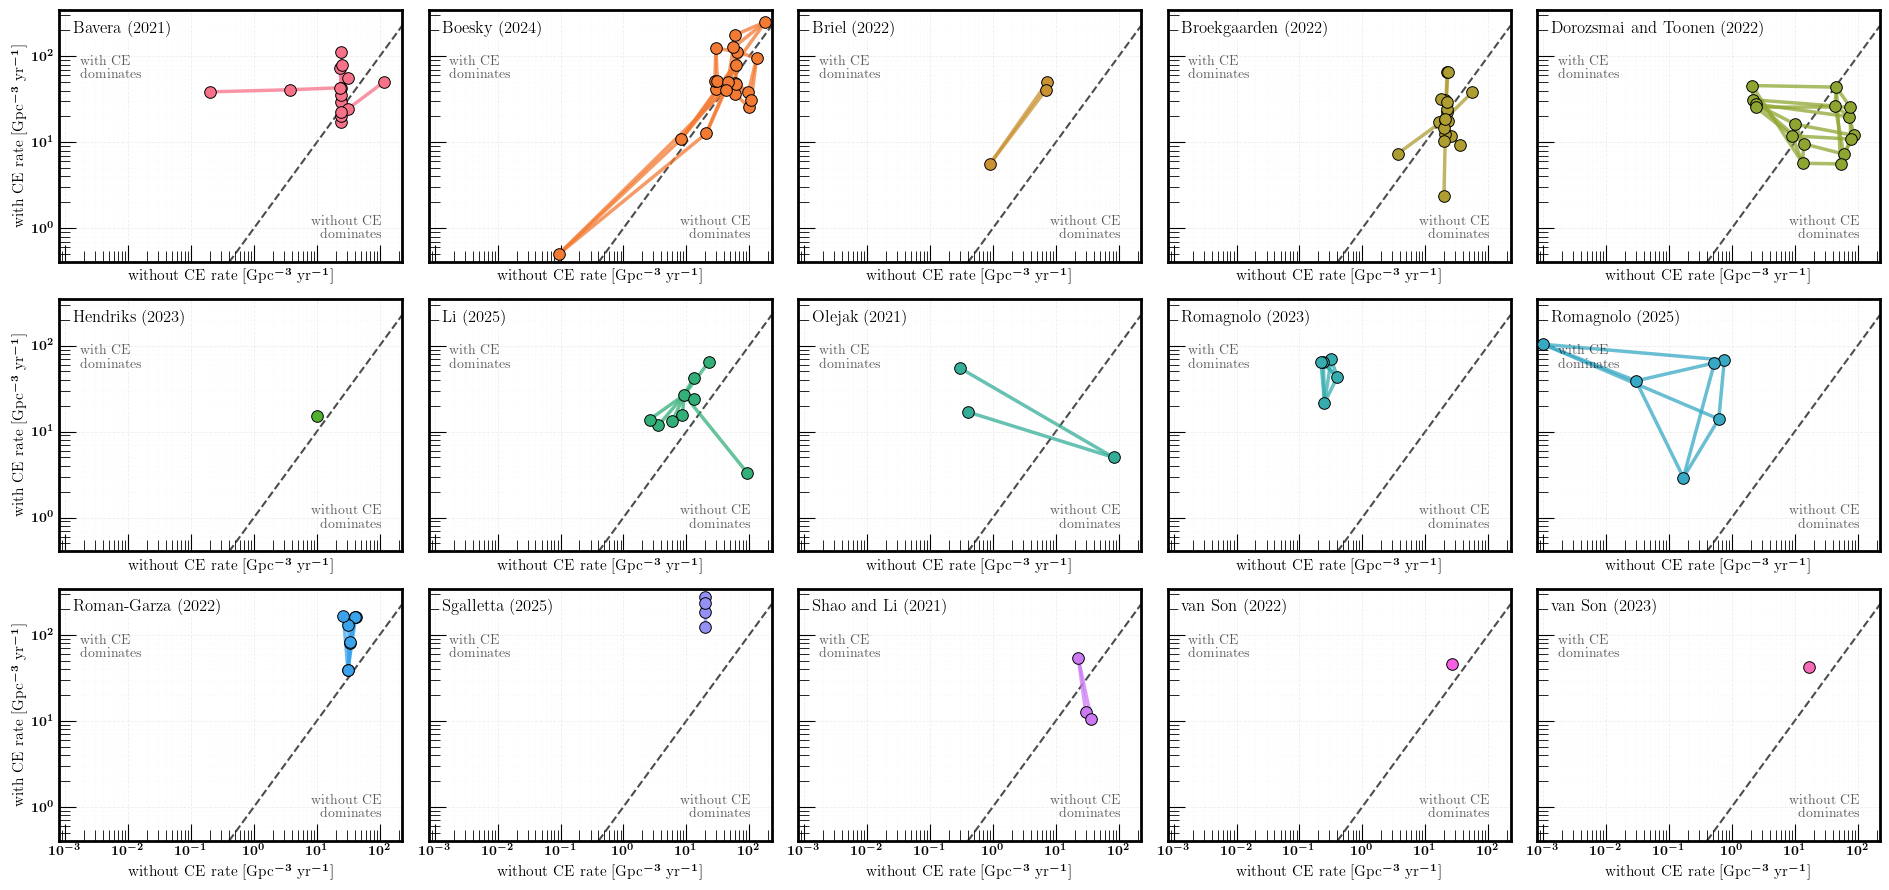

In [15]:
fig = plot_ce_vs_withoutce_rate_by_study_static(
    path_to_file="/Users/floorbroekgaarden/Projects/GitHub/Rates_of_Formation_Channels/plottingCode/All_Figures/Data_formation_channels_intrinsic/",
    DCOlabel="BH-BH",
    ncols_grid=5,
    panel_w=3.8,
    panel_h=3.0,
    marker_size=70,
    line_width=2.5,
    palette_name="husl",
)

fig.savefig(
    "Output_Figures/BHBH_withCE_vs_withoutCE_rate_grid.pdf",
    bbox_inches="tight"
)

plt.show()

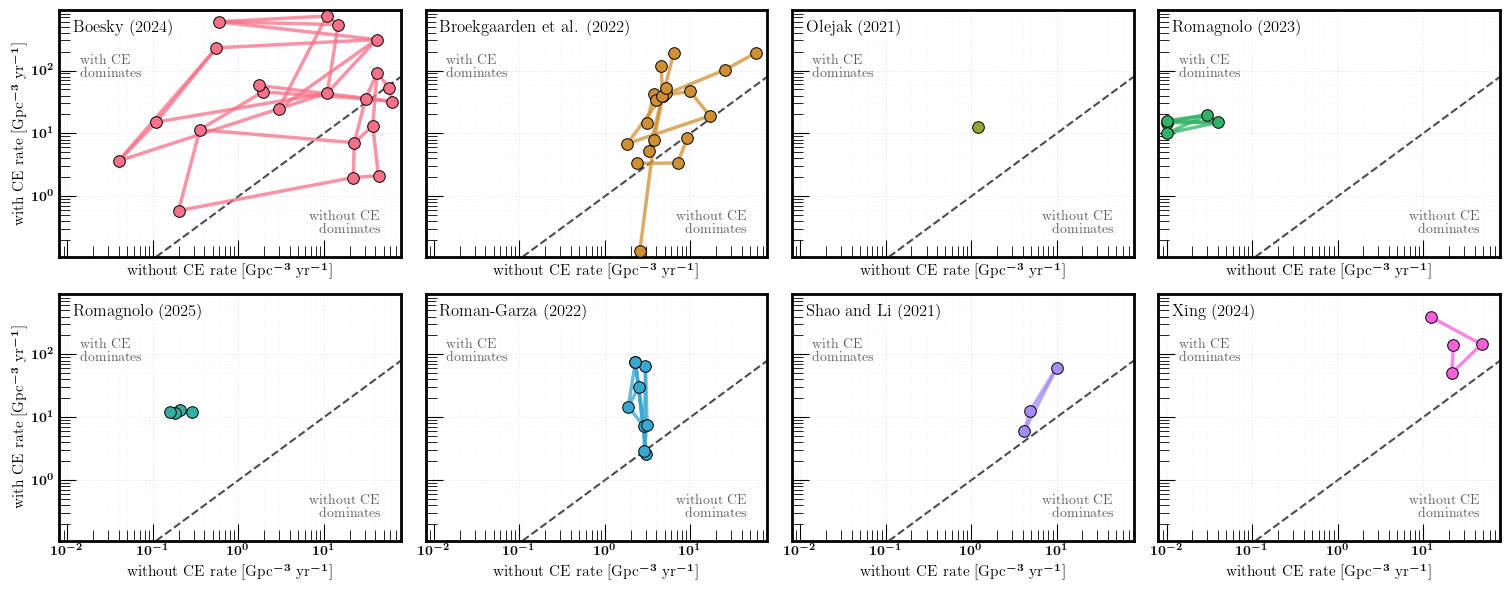

In [16]:
fig = plot_ce_vs_withoutce_rate_by_study_static(
    path_to_file="/Users/floorbroekgaarden/Projects/GitHub/Rates_of_Formation_Channels/plottingCode/All_Figures/Data_formation_channels_intrinsic/",
    DCOlabel="BH-NS",
    ncols_grid=4,
    panel_w=3.8,
    panel_h=3.0,
    marker_size=70,
    line_width=2.5,
    palette_name="husl",
)

fig.savefig(
    "Output_Figures/BHNS_withCE_vs_withoutCE_rate_grid.pdf",
    bbox_inches="tight"
)

plt.show()

### Extra plot; which parameter causes the biggest change

In [17]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


def plot_fc_change_by_parameter_family(
    path_to_file,
    DCOlabel="BH-BH",
    relation_file=None,
    fc_column="fraction without common envelope",
    used_column="using",
    legend_column="legend",
    from_column="from_modelname",
    to_column="to_modelname",
    cmap_name="husl",
    figsize=(9, 4.5),
    line_alpha=0.75,
    min_linewidth=1.5,
    max_linewidth=5.0,
    marker_size=45,
    sort_by="max_abs_change",  # "max_abs_change", "alphabetical"
    save_pdf=None,
    dpi=300,
    study_color_map=None  # add and use consistent color map for each simulation study
):
    """
    Plot the change in formation-channel contribution for each relationship.

    Each row in *_fcRelations.csv defines one relation: from_modelname -> to_modelname.
    For each relation, this computes

        Delta f = f(to_modelname) - f(from_modelname)

    where f is `fc_column`, e.g. "fraction without common envelope".

    The y-axis shows parameter/relationship families from the `used` column.
    Multiple studies using the same family are overplotted at the same y-position.
    """

    # --------------------------
    # Load files
    # --------------------------
    if relation_file is None:
        relation_file = f"{DCOlabel}_fcRelations.csv"

    rel_path = os.path.join(path_to_file, relation_file)
    rates_path = os.path.join(path_to_file, f"{DCOlabel}_rates_review.csv")

    df_rel = pd.read_csv(rel_path)
    df_rates = pd.read_csv(rates_path).fillna(0.0).set_index("model")

    if fc_column not in df_rates.columns:
        raise ValueError(
            f"fc_column={fc_column!r} not found in rates file. "
            f"Available columns include:\n{list(df_rates.columns)}"
        )

    required_rel_cols = [used_column, legend_column, from_column, to_column]
    missing = [c for c in required_rel_cols if c not in df_rel.columns]
    if missing:
        raise ValueError(
            f"Missing required columns in relation file: {missing}\n"
            f"Available columns are:\n{list(df_rel.columns)}"
        )

    # --------------------------
    # Compute Delta f per relation
    # --------------------------
    rows = []

    for _, row in df_rel.iterrows():
        family = row[used_column]
        study = row[legend_column]
        m_from = row[from_column]
        m_to = row[to_column]

        if pd.isna(family) or pd.isna(study):
            continue

        if m_from not in df_rates.index or m_to not in df_rates.index:
            continue

        f_from = float(df_rates.loc[m_from, fc_column])
        f_to = float(df_rates.loc[m_to, fc_column])

        if not np.isfinite(f_from) or not np.isfinite(f_to):
            continue

        delta = f_to - f_from
        abs_delta = abs(delta)

        rows.append({
            "family": str(family).strip(),
            "study": str(study).strip(),
            "from_model": m_from,
            "to_model": m_to,
            "f_from": f_from,
            "f_to": f_to,
            "delta": delta,
            "abs_delta": abs_delta,
        })

    df_delta = pd.DataFrame(rows)
    min_change = 0.10  # 10%

    family_max_change = df_delta.groupby("family")["abs_delta"].max()

    families_to_keep = family_max_change[
        family_max_change >= min_change
    ].index

    df_delta = df_delta[
        df_delta["family"].isin(families_to_keep)
    ].copy()

    print(
        f"Kept {len(families_to_keep)} families with at least one "
        f"|Δf| >= {min_change:.0%}"
    )

    if len(df_delta) == 0:
        raise ValueError("No valid relations found after matching relation models to rates table.")

    # --------------------------
    # Sort families
    # --------------------------
    if sort_by == "max_abs_change":
        families = (
            df_delta.groupby("family")["abs_delta"]
            .max()
            .sort_values(ascending=True)
            .index
            .tolist()
        )
    elif sort_by == "alphabetical":
        families = sorted(df_delta["family"].unique())
    else:
        raise ValueError("sort_by must be 'max_abs_change' or 'alphabetical'.")

    y_map = {family: i for i, family in enumerate(families)}

    studies = sorted(df_delta["study"].unique())

    if study_color_map is None:
        study_color_map = build_global_study_color_map(path_to_file, cmap_name=cmap_name)

    color_map = {
        study: study_color_map.get(normalize_study_label(study), "k")
        for study in studies
    }

    # Line styles help separate overlapping studies
    linestyles = ["-", "--", ":", "-."]
    linestyle_map = {
        study: linestyles[i % len(linestyles)]
        for i, study in enumerate(studies)
    }
    markers = ["o", "p", "D", "^", "v", "P", "X", "*", ">", "<"]
    marker_map = {
        study: markers[i % len(markers)]
        for i, study in enumerate(studies)
    }

    # Thicker lines for larger changes
    max_abs = df_delta["abs_delta"].max()
    if max_abs <= 0:
        max_abs = 1.0

    def linewidth_from_delta(abs_delta):
        return min_linewidth + (max_linewidth - min_linewidth) * (abs_delta / max_abs)

    # --------------------------
    # Plot
    # --------------------------
    fig, ax = plt.subplots(figsize=figsize)

    # Vertical zero line
#     ax.axvline(0, color="k", linewidth=1.0, alpha=0.6, zorder=0)

    for _, row in df_delta.iterrows():
        y = y_map[row["family"]]
        x0 = 0.0
        x1 = row["abs_delta"]
        study = row["study"]

        color = color_map[study]
        lw = linewidth_from_delta(row["abs_delta"])

        # Horizontal line from 0 to Delta f
        ax.plot(
            [x0, x1],
            [y, y],
            color=color,
            linestyle=linestyle_map[study],
            linewidth=lw,
            alpha=line_alpha,
            solid_capstyle="round",
            zorder=2,
        )

        # Marker at endpoint
        ax.scatter(
            x1,
            y,
            s=marker_size,
            color=color,
            marker=marker_map[study],
            edgecolor="k",
            linewidth=0.4,
            alpha=0.9,
            zorder=3,
        )

    # --------------------------
    # Axis formatting
    # --------------------------
    ax.set_yticks(range(len(families)))
    ax.set_yticklabels(families, fontsize=13)

    ax.set_xlabel(
        rf"$|\Delta$" +"fraction" + rf"$  |$",
        fontsize=16,
    )

#     ax.set_ylabel(r"$\textbf{Parameter / relationship family}$", fontsize=16)
    pretty_labels = [
        label_map.get(fam.lower(), fam)  # fallback = original name
        for fam in families
    ]

    ax.set_yticklabels(pretty_labels, fontsize=13)
    
    # Fractions are usually 0--1; show percent-like ticks if desired
    ax.set_xlim(0, 1.)
    ax.set_xticks(np.linspace(0, 1, 11))
#     ax.set_xticklabels([f"{float(x)}%" for x in np.linspace(0, 1, 11)])

    ax.grid(axis="x", alpha=0.25)
    ax.grid(axis="y", alpha=0.15)

    ax.tick_params(axis="both", which="major", direction="in", labelsize=16)

    # Legend: one entry per study
    handles = [
        plt.Line2D(
            [], [],
            color=color_map[study],
            linestyle=linestyle_map[study],
            linewidth=4.5,
            marker=marker_map[study],
            markersize=np.sqrt(marker_size),
            markerfacecolor=color_map[study],
            markeredgecolor="k",
            markeredgewidth=0.5,
            label=study,
        )
        for study in studies
    ]
    
    dict_temp = {'BH-NS': 'BHNS', 'BH-BH': 'BBH', 'NS-NS': 'BNS'}
    ax.legend(
        handles=handles,
        title=r"$\textbf{%s} \ \textbf{Study}$"%dict_temp[DCOlabel],
        frameon=False,
        fontsize=12,
        title_fontsize=11,
        loc="lower right",
        bbox_to_anchor=(.99, .01),
        handlelength=3.5
    )

    fig.tight_layout()

    if save_pdf is not None:
        fig.savefig(save_pdf, bbox_inches="tight", dpi=dpi, transparent=True)
        print(f"Saved figure to: {save_pdf}")

    return fig, ax, df_delta


label_map = {
    "alpha": r"$\alpha_{\rm CE}$",
    "beta": r"$\beta$",
    "stability": r"$q_{\rm c}$",
    "sigma": r"$\sigma$",
    "kick velocity": r"$\sigma_{\rm kick}$",
    "remnant mass prescription": r"remnant mass prescription",
    "supernova": r"SN engine",
    "wind": r"stellar winds",
    "optimistic":"optimistic CE",
    "gamma": r"$\gamma$"
    
}

Kept 11 families with at least one |Δf| >= 10%
Saved figure to: /Users/floorbroekgaarden/Projects/GitHub/Rates_of_Formation_Channels/plottingCode/All_Figures/Output_Figures/extra_Fig_parameter_family_delta_withoutCE_BHBH.pdf
Kept 7 families with at least one |Δf| >= 10%
Saved figure to: /Users/floorbroekgaarden/Projects/GitHub/Rates_of_Formation_Channels/plottingCode/All_Figures/Output_Figures/extra_Fig_parameter_family_delta_withoutCE_BHNS.pdf


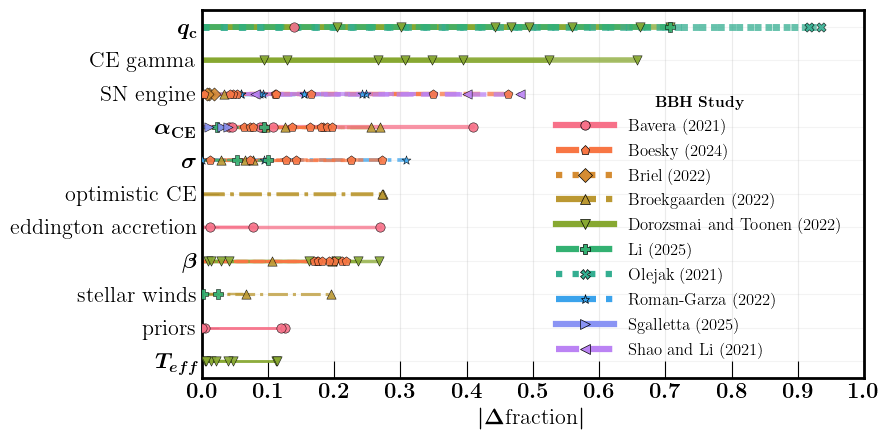

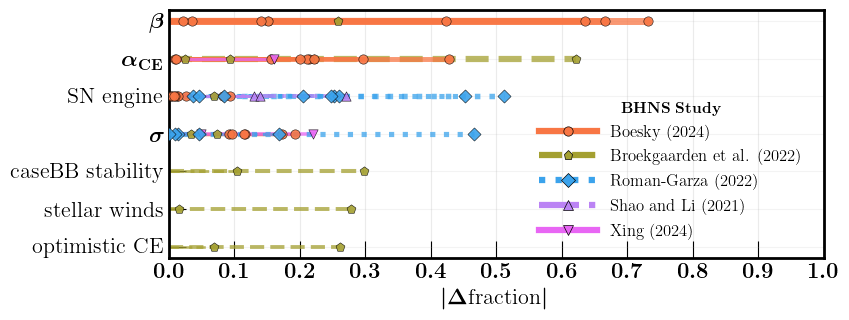

In [18]:
data_path = "/Users/floorbroekgaarden/Projects/GitHub/Rates_of_Formation_Channels/plottingCode/All_Figures/Data_formation_channels_intrinsic/"

# set up global color map consistent colors for each study across code 
global_study_color_map = build_global_study_color_map(path_to_file, cmap_name="husl",)

fig, ax, df_delta = plot_fc_change_by_parameter_family(
    path_to_file=data_path,
    DCOlabel="BH-BH",
    fc_column="fraction without common envelope",
    save_pdf="/Users/floorbroekgaarden/Projects/GitHub/Rates_of_Formation_Channels/plottingCode/All_Figures/Output_Figures/extra_Fig_parameter_family_delta_withoutCE_BHBH.pdf",
    study_color_map=global_study_color_map
)


fig, ax, df_delta = plot_fc_change_by_parameter_family(
    path_to_file=data_path,
    DCOlabel="BH-NS",
    figsize=(8.6, 3.3),
    fc_column="fraction without common envelope",
    save_pdf="/Users/floorbroekgaarden/Projects/GitHub/Rates_of_Formation_Channels/plottingCode/All_Figures/Output_Figures/extra_Fig_parameter_family_delta_withoutCE_BHNS.pdf",
    study_color_map=global_study_color_map
)






In [19]:
print(np.linspace(0, 1, 11))

[0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]


In [20]:
# one combined figure 

In [21]:
# def plot_fc_change_by_parameter_family(
#     path_to_file,
#     DCOlabel,
#     fc_column,
#     ax=None,
#     figsize=(4.3, 3.3),
#     save_pdf=None,
# ):
#     if ax is None:
#         fig, ax = plt.subplots(figsize=figsize)
#     else:
#         fig = ax.figure

#     # --- existing plotting code ---
#     # make sure all plotting uses `ax` and NOT plt

#     return fig, ax, df_delta


# import matplotlib.pyplot as plt

# data_path = "/Users/floorbroekgaarden/Projects/GitHub/Rates_of_Formation_Channels/plottingCode/All_Figures/Data_formation_channels_intrinsic/"

# fig, axes = plt.subplots(
#     1, 2,
#     figsize=(8.6, 3.3),
#     sharey=True
# )

# # --- BBH ---
# fig, axes[0], df_bbh = plot_fc_change_by_parameter_family(
#     path_to_file=data_path,
#     DCOlabel="BH-BH",
#     fc_column="fraction without common envelope",
#     ax=axes[0],
# )

# axes[0].set_title(r"$\mathrm{BBH}$")

# # --- BHNS ---
# fig, axes[1], df_bhns = plot_fc_change_by_parameter_family(
#     path_to_file=data_path,
#     DCOlabel="BH-NS",
#     fc_column="fraction without common envelope",
#     ax=axes[1],
# )

# axes[1].set_title(r"$\mathrm{BHNS}$")

# # --- formatting ---
# for ax in axes:
#     ax.grid(True, alpha=0.3)

# plt.tight_layout()

# # Save
# fig.savefig(
#     "/Users/floorbroekgaarden/Projects/GitHub/Rates_of_Formation_Channels/plottingCode/All_Figures/Output_Figures/extra_Fig_parameter_family_delta_withoutCE_combined.pdf",
#     bbox_inches="tight"
# )